# Invoice Audit — Meridian Health Assurance Group

**Task:** five hospitals bill a health insurer under five separately negotiated
contracts. Some invoices are wrong. Find them.

**Data:** ~62,000 line items across ~4,900 invoices. Hospital 1 is labelled and is
used only for development. Hospitals 2-5 are scored.

---

## 📌 How this notebook is organised

The notebook **is** the build. Sections that define real logic write it out to `src/`
with `%%writefile`, so running this notebook top to bottom produces the repository,
the evaluation numbers, and `submission.csv`.

| Section | What happens |
|---|---|
| 0️⃣ | Setup — fetch the data, imports |
| 1️⃣ | Exploratory data analysis — what are we actually looking at? |
| 2️⃣ | The checks that need no contract at all |
| 3️⃣ | Reading the contracts |
| 4️⃣ | Matching billing descriptions to contracted services |
| 5️⃣ | The repricing engine |
| 6️⃣ | Evaluation on hospital 1 |
| 7️⃣ | Hospital 5 — does any of it travel? |
| 8️⃣ | Where an LLM earns its place, and which one |
| 9️⃣ | Confidence and calibration |
| 🔟 | Build `submission.csv` |

**Design principle, stated once:** the LLM reads English. Python does arithmetic.
No number a model produces is trusted until the deterministic engine reproduces it.

---

# 0️⃣ Setup

Everything below runs unchanged on Colab and on a local machine. The only
difference is that Colab starts empty, so we clone the dataset first.

In [1]:
# The dataset lives in a public repository. On Colab this clones it;
# locally it is skipped because the folder already exists.
import os, subprocess, sys

DATA_REPO = 'https://github.com/majedzahrani3/insurance_auditing.git'

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.exists('insurance_auditing'):
        subprocess.run(['git', 'clone', '--depth', '1', DATA_REPO], check=True)
    PROJECT = '/content'
    DATA    = '/content/insurance_auditing'
else:
    PROJECT = os.path.abspath('..')      # the repo root, when run from notebooks/
    DATA    = os.path.join(PROJECT, 'data')

for folder in ['src', 'prompts', 'reports', 'runs']:
    os.makedirs(os.path.join(PROJECT, folder), exist_ok=True)
if PROJECT not in sys.path:
    sys.path.insert(0, PROJECT)
os.chdir(PROJECT)          # so %%writefile can use short paths like src/foo.py

print(f'running on colab : {IN_COLAB}')
print(f'project root     : {PROJECT}')
print(f'data root        : {DATA}')

running on colab : False
project root     : /Users/saudimaldini/Downloads/invoice-audit
data root        : /Users/saudimaldini/Downloads/invoice-audit/data


In [2]:
# Everything we use. Deliberately ordinary: pandas for tables, matplotlib for
# charts, scikit-learn for one similarity calculation, Decimal for exact money.
import collections
import re
import textwrap
from decimal import Decimal, ROUND_HALF_UP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

HOSPITALS = [f'hospital_{i}' for i in range(1, 6)]
DEV_HOSPITAL = 'hospital_1'          # the only labelled one
SCORED = HOSPITALS[1:]               # hospitals 2-5 go in the submission

print(f'pandas {pd.__version__} | numpy {np.__version__}')
print(f'development set : {DEV_HOSPITAL}')
print(f'scored          : {SCORED}')

pandas 2.0.3 | numpy 1.26.4
development set : hospital_1
scored          : ['hospital_2', 'hospital_3', 'hospital_4', 'hospital_5']


In [3]:
# Confirm the files are actually where we think they are before going further.
import glob

for sub in ['contracts', 'invoices', 'labels']:
    found = sorted(glob.glob(os.path.join(DATA, sub, '*')))
    print(f'{sub:10s} {len(found):2d} entries   e.g. {os.path.basename(found[0])}')

contracts   5 entries   e.g. hospital_1
invoices   15 entries   e.g. hospital_1_invoices.csv
labels      1 entries   e.g. hospital_1_labels.csv


> ✅ Data is in place. Nothing above touches a model — the next four sections are
> entirely deterministic Python, and they will get us most of the way.

---

# 1️⃣ Exploratory Data Analysis

**Why bother?** Because three things in this dataset are not what they look like,
and each one silently corrupts everything downstream if you miss it. Better to find
them now with a `value_counts()` than at the end with a wrong submission.

We are looking for:
- how big is this, really
- how rare are the errors (this decides which metric is honest)
- how the same service gets described differently
- how differently the five contracts are written

## Step 1 — How much data is there?

In [4]:
def load_invoices(hospital):
    """One row per invoice. Money stays an integer number of cents."""
    df = pd.read_csv(f'{DATA}/invoices/{hospital}_invoices.csv', dtype=str)
    df['invoice_total_cents'] = pd.to_numeric(df['invoice_total_cents']).astype('Int64')
    return df

def load_line_items(hospital):
    """One row per line item."""
    df = pd.read_csv(f'{DATA}/invoices/{hospital}_line_items.csv', dtype=str)
    for c in ['quantity', 'unit_price_cents', 'line_total_cents']:
        df[c] = pd.to_numeric(df[c]).astype('Int64')
    return df

sizes = []
for h in HOSPITALS:
    inv, li = load_invoices(h), load_line_items(h)
    sizes.append({'hospital': h,
                  'invoice_rows': len(inv),
                  'unique_invoice_ids': inv.invoice_id.nunique(),
                  'line_items': len(li),
                  'lines_per_invoice': round(len(li) / inv.invoice_id.nunique(), 1)})

sizes = pd.DataFrame(sizes)
print(f'TOTAL: {sizes.invoice_rows.sum():,} invoice rows and {sizes.line_items.sum():,} line items')
sizes

TOTAL: 4,886 invoice rows and 61,211 line items


,hospital,invoice_rows,unique_invoice_ids,line_items,lines_per_invoice
0,hospital_1,918,913,11415,12.5
1,hospital_2,1132,1125,14360,12.8
2,hospital_3,939,932,11655,12.5
3,hospital_4,840,835,10560,12.6
4,hospital_5,1057,1050,13221,12.6


> Roughly 4,900 invoices and 62,000 line items, spread fairly evenly across the
> five hospitals at about 12 line items each.

>> Look at `invoice_rows` against `unique_invoice_ids` — they **do not match**. Every
>> hospital has more rows than identifiers. That is the first trap, and we come back
>> to it in Step 2.

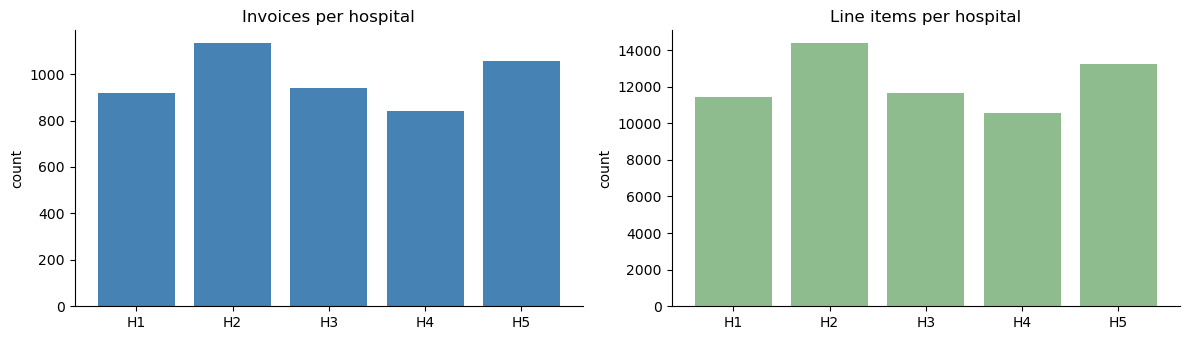

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(sizes.hospital.str.replace('hospital_', 'H'), sizes.invoice_rows, color='steelblue')
ax[0].set_title('Invoices per hospital'); ax[0].set_ylabel('count')
ax[1].bar(sizes.hospital.str.replace('hospital_', 'H'), sizes.line_items, color='darkseagreen')
ax[1].set_title('Line items per hospital'); ax[1].set_ylabel('count')
plt.tight_layout(); plt.show()

## Step 2 — `invoice_id` is not a key

The counts above say some identifiers appear twice. Two possibilities: either the
row is duplicated (harmless, drop one), or **two different invoices are wearing the
same name tag** (not harmless at all). Let us look.

In [6]:
inv = load_invoices('hospital_1')
dup_ids = inv[inv.duplicated('invoice_id', keep=False)].invoice_id.unique()
print(f'identifiers used more than once: {len(dup_ids)}')

inv[inv.invoice_id == dup_ids[0]][['invoice_id', 'invoice_date', 'patient_id',
                                   'plan_tier', 'invoice_total_cents']]

identifiers used more than once: 5


,invoice_id,invoice_date,patient_id,plan_tier,invoice_total_cents
67,INV-H1-000068,2024-03-04,PT-H1-000054,SILVER,2123825
154,INV-H1-000068,2024-05-20,PT-H1-000021,BRONZE,2182165


> Different patient, different date, different total — the **same identifier**. These
> are two genuinely different invoices, not a duplicated row. Dropping one would
> throw away a real invoice; merging them would invent a fictional one.

>> So what *is* unique? The `line_id` gives it away.

In [7]:
li = load_line_items('hospital_1')
# line_id looks like 'H1-L00068-01': hospital, invoice sequence, line number.
li['source_seq'] = li.line_id.str.split('-').str[1]

g = li[li.invoice_id == dup_ids[0]].groupby('source_seq').line_total_cents.sum()
print(f'line groups inside {dup_ids[0]}:')
print(g.to_string())
print()
print('invoice totals stated for that id:',
      list(inv.loc[inv.invoice_id == dup_ids[0], 'invoice_total_cents']))

line groups inside INV-H1-000068:
source_seq
L00068    2123825
L00155    2182165

invoice totals stated for that id: [2123825, 2182165]


> The line items split into **two groups by `line_id` prefix**, and the two groups sum
> to exactly the two stated invoice totals. So `line_id` carries the true invoice
> number, and `INV-H1-000068` is really invoices `L00068` and `L00155` sharing a tag.

>> **Decision:** the real key is the `line_id` prefix, not `invoice_id`. Everything
>> downstream prices an invoice *unit*. Reusing an identifier is itself one of the
>> error categories, so we flag the later of the pair and leave the first alone.

## Step 3 — How rare are the errors?

This decides which metric is honest. If errors are rare, *accuracy* is meaningless:
a model that flags nothing at all scores extremely well and is useless.

In [8]:
labels = pd.read_csv(f'{DATA}/labels/hospital_1_labels.csv', dtype=str)
labels['is_erroneous'] = labels.is_erroneous.astype(int)
labels['categories'] = labels.error_categories.fillna('').apply(
    lambda s: [c.strip() for c in s.split('|') if c.strip()])

n, bad = len(labels), labels.is_erroneous.sum()
print(f'labelled invoices : {n}')
print(f'erroneous         : {bad}  ({bad/n:.1%})')
print(f'clean             : {n-bad}  ({(n-bad)/n:.1%})')
print()
print(f'A model that flags NOTHING scores {(n-bad)/n:.1%} accuracy — and finds zero errors.')
print('So accuracy is not reported anywhere in this notebook. Precision and recall are.')

labelled invoices : 913
erroneous         : 58  (6.4%)
clean             : 855  (93.6%)

A model that flags NOTHING scores 93.6% accuracy — and finds zero errors.
So accuracy is not reported anywhere in this notebook. Precision and recall are.


> Only **6.4%** of invoices are erroneous. Always-say-no scores 93.6% accuracy while
> being completely worthless, which is why accuracy never appears again below.

>> We report **precision** (of what we flagged, how much was really wrong) and
>> **recall** (of what was really wrong, how much we caught).

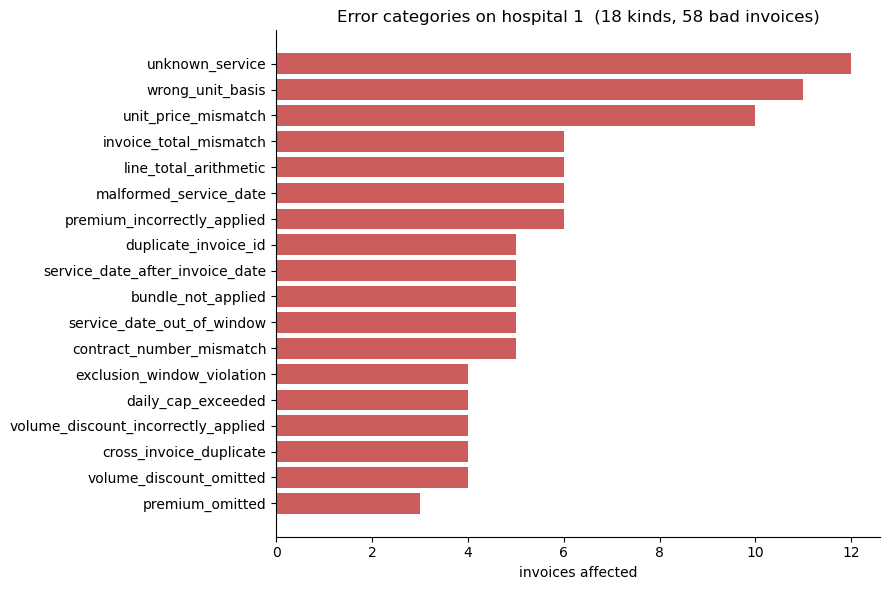

categories per erroneous invoice: {1: 18, 2: 33, 3: 7}


In [9]:
cat_counts = collections.Counter(c for cats in labels.categories for c in cats)
cats = pd.Series(cat_counts).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(cats.index, cats.values, color='indianred')
plt.title(f'Error categories on hospital 1  ({len(cats)} kinds, {bad} bad invoices)')
plt.xlabel('invoices affected')
plt.tight_layout(); plt.show()

per_invoice = collections.Counter(len(c) for c in labels.categories if c)
print('categories per erroneous invoice:', dict(sorted(per_invoice.items())))

> Eighteen distinct categories, none with more than 12 examples. Most bad invoices
> carry **two or three at once**, so this is multi-label, not a single choice.

>> With supports this small, a per-category recall of 1.0 on four examples is weak
>> evidence. Every table below prints the support column for that reason.

## Step 4 — The same service, described many ways

The brief warns that *"the invoice descriptions never match the contract wording,
because real billing systems don't work that way."* Let us see how bad it is.

In [10]:
print(f'line items          : {len(li):,}')
print(f'unique descriptions : {li.description.nunique()}')
print()
print('a random sample:')
for d in li.description.drop_duplicates().sample(12, random_state=0):
    print('   ', d)

line items          : 11,415
unique descriptions : 488

a random sample:
    Ambulatory  Pulm Recov Rm Occupancy /NG-9869
    Svc Routine Derm Transf /NG-2484
    Emer Ortho Consult
    Emer Ortho
    Ortho Transp Svc
    Std Endocrine Endosc Proc
    Occupancy Rtn Pall Crit Cr
    Inpt Musculoskeletal Wd Bed Occupancy /NG-8170
    Emer Ortho Rehabilitation Prog
    Occ Routine Infectious Critical Cr
    Rtn - Urol Biop Procedure
    Spclst - Ent Thtr Tm /NG-7710


> Abbreviated (`Rtn`, `Compr`, `Ent` for Otolaryngologic), reordered
> (`Occupancy Rtn Pall Crit Cr`), truncated (`Extended Ren Transp`), and suffixed with
> noise codes (`/NG-3022`). Word-level matching will not survive this.

>> The important number is the *ratio*: how many descriptions per actual service?

contracted services : 108
unique descriptions : 488
aliases per service : 4.5


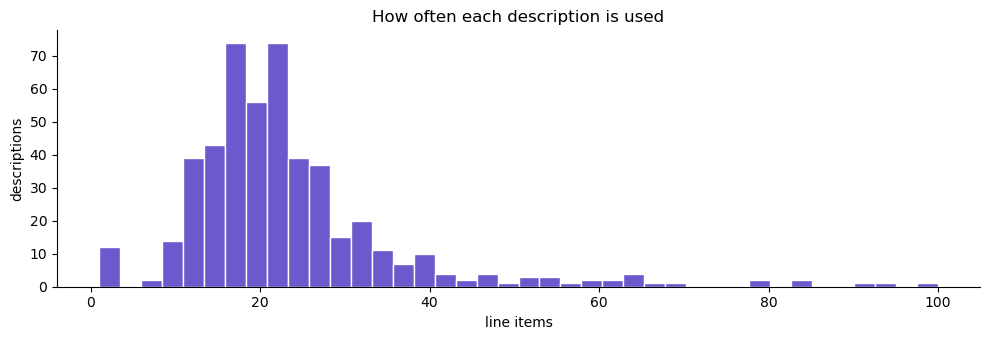

used exactly once: 12 descriptions


In [11]:
contract = open(f'{DATA}/contracts/hospital_1/provider_services_agreement.md').read()
rate_block = contract.split('## 4. Rate Schedule')[1].split('## 5.')[0]
services = [l.split('|')[1].strip() for l in rate_block.strip().splitlines()
            if l.startswith('|') and '---' not in l][1:]

print(f'contracted services : {len(services)}')
print(f'unique descriptions : {li.description.nunique()}')
print(f'aliases per service : {li.description.nunique() / len(services):.1f}')

uses = li.description.value_counts()
plt.figure(figsize=(10, 3.5))
plt.hist(uses.values, bins=40, color='slateblue', edgecolor='white')
plt.title('How often each description is used'); plt.xlabel('line items'); plt.ylabel('descriptions')
plt.tight_layout(); plt.show()
print(f'used exactly once: {(uses == 1).sum()} descriptions')

> 108 services wearing 488 different descriptions — about **4.5 aliases each**.

>> The histogram has a spike at 1. A handful of descriptions appear exactly once,
>> while genuine aliases are used dozens of times. That spike turns out to matter a
>> great deal in Section 4️⃣ — a description used once is not an established alias.

## Step 5 — The five contracts are written completely differently

This is the part that decides where an LLM is needed and where it is not.

In [12]:
shapes = []
for h in HOSPITALS:
    docs = sorted(glob.glob(f'{DATA}/contracts/{h}/*.md'))
    text = ''.join(open(d).read() for d in docs)
    table_rows = len([l for l in text.splitlines() if l.strip().startswith('|')])
    shapes.append({'hospital': h,
                   'documents': len(docs),
                   'characters': len(text),
                   'approx_tokens': len(text) // 4,
                   'table_rows': table_rows,
                   'format': 'TABULAR' if table_rows > 50 else 'PROSE'})
shapes = pd.DataFrame(shapes)
shapes

,hospital,documents,characters,approx_tokens,table_rows,format
0,hospital_1,1,15863,3965,165,TABULAR
1,hospital_2,1,148145,37036,0,PROSE
2,hospital_3,3,22243,5560,217,TABULAR
3,hospital_4,1,18945,4736,172,TABULAR
4,hospital_5,1,25270,6317,317,TABULAR


> Four contracts are tables. **Hospital 2 has literally zero table rows** and is nine
> times longer than any other. That single row of the table is the entire reason an
> LLM appears in this project at all.

In [13]:
h1 = open(f'{DATA}/contracts/hospital_1/provider_services_agreement.md').read()
h2 = open(f'{DATA}/contracts/hospital_2/master_services_agreement.md').read()

print('HOSPITAL 1 states a rate like this:'); print('-' * 68)
rows = [l for l in rate_block.strip().splitlines() if l.strip().startswith('|')]
print('\n'.join(rows[:4]))
print()
print('HOSPITAL 2 states a rate like this:'); print('-' * 68)
clause = [l for l in h2.splitlines() if l.startswith('4.2 ')][0]
import textwrap; print(textwrap.fill(clause, 68))

HOSPITAL 1 states a rate like this:
--------------------------------------------------------------------
| Service | Unit basis | Rate | Daily cap |
|---|---|---|---|
| Advanced Cardiac Recovery Room Occupancy | per hour | GBP 200.00 | — |
| Advanced Haematology Physiotherapy Session | per hour | GBP 101.50 | — |

HOSPITAL 2 states a rate like this:
--------------------------------------------------------------------
4.2 In respect of Assisted Infectious Telemetry Monitoring, the
Provider shall invoice the Payer at the rate of GBP 106.25 per hour,
per item. The Provider shall be able to demonstrate, from its
clinical record, the quantity billed for this Service on any Service
Day. Where an invoice presents this Service on a unit basis other
than the one stated in this clause, the line item shall be treated
as incorrectly presented and shall be returned to the Provider. The
description applied by the Provider on any invoice shall not of
itself vary the rate applicable to this Service; t

> Same kind of fact. One is a table row a regex reads in microseconds; the other is
> 120 words of legal prose wrapped around three usable values (the service name, the
> rate `10625`, and the unit basis `per_hour_per_item`).

>> **This is what "prose" means, and why hospital 2 is the hard one.**

In [14]:
# How much of hospital 2 actually carries rates?
articles = re.split(r'^## ', h2, flags=re.M)[1:]
rate_articles = [a for a in articles if 'Contracted Services' in a.splitlines()[0]]
other = [a for a in articles if 'Contracted Services' not in a.splitlines()[0]]
clauses = len(re.findall(r'^\d+\.\d+ In respect of', h2, flags=re.M))

rate_tok = sum(len(a) // 4 for a in rate_articles)
other_tok = sum(len(a) // 4 for a in other)
print(f'articles total              : {len(articles)}')
print(f'  carrying rates            : {len(rate_articles)}  ->  {rate_tok:,} tokens')
print(f'  boilerplate               : {len(other)}  ->  {other_tok:,} tokens')
print(f'individual rate clauses     : {clauses}')
print()
print(f'{other_tok/(rate_tok+other_tok):.0%} of hospital 2 is Force Majeure, Data Protection, Confidentiality...')
print('A one-line filter on the heading removes all of it, with no recall risk.')

articles total              : 35
  carrying rates            : 13  ->  18,769 tokens
  boilerplate               : 22  ->  18,138 tokens
individual rate clauses     : 76

49% of hospital 2 is Force Majeure, Data Protection, Confidentiality...
A one-line filter on the heading removes all of it, with no recall risk.


> Only **51%** of hospital 2 carries rates. The rest is boilerplate.

>> This is the retrieval decision, settled by measurement rather than fashion. We do
>> not need embeddings to find the rate clauses — the headings say which articles they
>> are. And we need **all thirteen**, not the top-k most similar, so similarity search
>> is the wrong tool by construction. Section 8️⃣ builds the embedding version anyway
>> and measures it, so the choice is defended with a number rather than an opinion.

## Step 6 — Should we clean the data?

The standard next move after EDA is data cleaning: drop the nulls, remove the
duplicates, clip the outliers, impute the gaps.

**Every one of those would be wrong here.** Let us prove it rather than assert it.

In [15]:
audit = []
for h in HOSPITALS:
    inv_h = load_invoices(h)
    li_h  = load_line_items(h)
    # Dates arrive as text, so nulls only appear once we try to parse them.
    parsed = pd.to_datetime(li_h.service_date, format='%Y-%m-%d', errors='coerce')
    audit.append({
        'hospital': h,
        'unparseable_dates': int(parsed.isna().sum()),
        'other_nulls': int(inv_h.isna().sum().sum() + li_h.drop(columns=['service_date']).isna().sum().sum()),
        'quantity <= 0': int((li_h.quantity <= 0).sum()),
        'unit_price <= 0': int((li_h.unit_price_cents <= 0).sum()),
        'orphan_line_items': int((~li_h.invoice_id.isin(set(inv_h.invoice_id))).sum()),
        'invoices_without_lines': int((~inv_h.invoice_id.isin(set(li_h.invoice_id))).sum()),
    })
pd.DataFrame(audit)

,hospital,unparseable_dates,other_nulls,quantity <= 0,unit_price <= 0,orphan_line_items,invoices_without_lines
0,hospital_1,6,0,0,0,0,0
1,hospital_2,8,0,0,0,0,0
2,hospital_3,7,0,0,0,0,0
3,hospital_4,6,0,0,0,0,0
4,hospital_5,8,0,0,0,0,0


In [16]:
li_h = load_line_items('hospital_1')
parsed = pd.to_datetime(li_h.service_date, format='%Y-%m-%d', errors='coerce')
bad_dates = li_h[parsed.isna()]

print(f'line items with a service_date that is not a real date: {len(bad_dates)}')
print()
print('the actual values:')
for v in bad_dates.service_date.tolist():
    print('   ', repr(v))

line items with a service_date that is not a real date: 6

the actual values:
    '2025-06-31'
    'not-a-date'
    '2024-00-17'
    '31/02/2024'
    '2025-02-30'
    '2025-06-31'


> The dataset is structurally spotless. No negative quantities, no zero prices, no
> orphan line items, no invoices without lines.

> **The only nulls in the whole dataset are the broken service dates** — and those are
> `malformed_service_date`, one of the eighteen error categories we are paid to find.
> `2025-06-31` does not exist; June has thirty days.

>> So `df.dropna()` — the most routine line in any pipeline — would delete exactly the
>> findings. **In this project the dirt is the signal, not the noise.**

### What that means for every cleaning instinct

| The usual move | What it would destroy here |
|---|---|
| `dropna()` | all 6 `malformed_service_date` errors |
| `drop_duplicates()` | all 5 `duplicate_invoice_id` errors |
| clip or remove price outliers | `unit_price_mismatch`, the largest category |
| impute missing with the mean | invents a date that was never on the invoice |
| scale or normalise the numbers | breaks exact-cent matching, which is the whole method |

### What we do instead

We change how the data is **written**, never what it **says**:

| Transformation | Why |
|---|---|
| money as whole cents (`Int64`, never float) | a float rounding slip is indistinguishable from a billing error |
| parse dates *and keep the raw string* | `NaT` for the checker, the original text for the evidence trail |
| sort by service date, then line id | the contracts require exactly this order for counting |
| derive `source_seq` from `line_id` | adds a column, alters nothing |
| map `per item supplied` → `per_item` | contract and invoice use different words for one unit |

Not one of those changes a value.

>> **And no averages.** There is one "most common value" in the whole project — the
>> typical price of a description, in section 4️⃣, used to identify *which service it is*.
>> We never average money. The mean of a correct price and an incorrect one is a number
>> that appears on no invoice and in no contract.

---

## 🔎 What the EDA settled

| Finding | Consequence |
|---|---|
| `invoice_id` is not unique; `line_id` prefix is | Price *units*, not ids. Reused ids are themselves an error |
| Errors are 6.4% of invoices | Never report accuracy. Precision and recall only |
| 18 categories, 2-3 per bad invoice, tiny supports | Multi-label; always print support |
| 108 services, 488 descriptions, 4.5 aliases each | Text matching alone will not do it |
| Descriptions used exactly once are unusual | A signal we exploit in 4️⃣ |
| 4 contracts tabular, hospital 2 prose and 9x longer | The LLM is for hospital 2, and nothing else |
| 49% of hospital 2 is boilerplate under known headings | Filter structurally, not semantically |

Next: the errors we can find **without reading a single contract**.

---

# 2️⃣ The errors you can find without reading a contract

Before touching a contract or a model, notice this: some errors are just **facts**.

If a line says `3 x £50 = £200`, that is wrong. You do not need the contract to know
that. If a service is dated after the invoice that bills it, that is wrong too.

There are **seven** checks like this. They are free, they never guess, and they run on
all five hospitals. Let us see how far they get us.

## Step 1 — Fix the invoice key first

Section 1️⃣ found that `invoice_id` is not unique, and that the `line_id` prefix is.
Every check below depends on getting this right, so we do it first and write it out
to a file we can import later.

In [17]:
%%writefile src/data_loader.py
"""Loading the invoice data, and rebuilding the real invoice key.

Two rules govern this module:

1. Money stays an integer number of cents. We never let pandas infer a float for a
   monetary column, because a rounding error would then be indistinguishable from a
   billing error.
2. Dates are parsed without destroying the original. `malformed_service_date` is one
   of the errors we must detect, so the raw string is kept next to the parsed value
   and a bad date becomes NaT rather than raising.

A third rule came from the data rather than the brief: `invoice_id` is not a key.
Five hospital_1 identifiers are each carried by two genuinely different invoices.
The `line_id` prefix is unique, so that is the real key.
"""

import pandas as pd

MONEY = ['invoice_total_cents', 'unit_price_cents', 'line_total_cents']


def load_invoices(data_root, hospital):
    """One row per invoice row (note: not per invoice — see build_invoice_units)."""
    df = pd.read_csv(f'{data_root}/invoices/{hospital}_invoices.csv', dtype=str)
    df['invoice_total_cents'] = pd.to_numeric(df['invoice_total_cents']).astype('Int64')
    for c in ['invoice_date', 'admission_date', 'discharge_date']:
        df[c + '_raw'] = df[c]
        df[c] = pd.to_datetime(df[c], format='%Y-%m-%d', errors='coerce')
    return df


def load_line_items(data_root, hospital):
    """One row per line item, sorted the way the contracts require them counted.

    Several rules are defined over line items 'in Service Date order, and where two
    line items share a Service Date, in ascending order of line identifier'. We sort
    once here so every later pass inherits that order.
    """
    df = pd.read_csv(f'{data_root}/invoices/{hospital}_line_items.csv', dtype=str)
    for c in ['quantity', 'unit_price_cents', 'line_total_cents']:
        df[c] = pd.to_numeric(df[c]).astype('Int64')
    df['service_date_raw'] = df['service_date']
    df['service_date'] = pd.to_datetime(df['service_date'], format='%Y-%m-%d', errors='coerce')
    df['source_seq'] = df['line_id'].str.split('-').str[1]      # 'H1-L00068-01' -> 'L00068'
    return df.sort_values(['service_date', 'line_id'], na_position='last').reset_index(drop=True)


def build_invoice_units(invoices, line_items):
    """Attach the real invoice key (`source_seq`) to every invoice row.

    Where an identifier is reused, the rows are paired with their line groups in
    ascending order of both invoice date and line sequence. That pairing reproduces
    the stated invoice totals exactly for all five reused identifiers on hospital 1,
    and the label file always describes the *later* of the pair. So we treat the
    earlier invoice as legitimate and flag the later one.
    """
    groups = (line_items.groupby(['invoice_id', 'source_seq'])['line_total_cents']
                        .sum().reset_index().sort_values(['invoice_id', 'source_seq']))
    inv = invoices.sort_values(['invoice_id', 'invoice_date']).copy()

    inv['_rank'] = inv.groupby('invoice_id').cumcount()
    groups['_rank'] = groups.groupby('invoice_id').cumcount()
    merged = inv.merge(groups[['invoice_id', 'source_seq', '_rank']],
                       on=['invoice_id', '_rank'], how='left')
    merged['reuses_id'] = merged['_rank'] > 0
    return merged.drop(columns='_rank')


def load_labels(data_root, hospital='hospital_1'):
    """Ground truth for the development hospital. Categories are `|`-separated."""
    df = pd.read_csv(f'{data_root}/labels/{hospital}_labels.csv', dtype=str)
    df['is_erroneous'] = df['is_erroneous'].astype(int)
    df['expected_total_cents'] = pd.to_numeric(df['expected_total_cents']).astype('Int64')
    df['categories'] = df['error_categories'].fillna('').apply(
        lambda s: [c.strip() for c in s.split('|') if c.strip()])
    return df

Overwriting src/data_loader.py


In [18]:
import importlib
import src.data_loader as dl
importlib.reload(dl)

invoices  = dl.load_invoices(DATA, 'hospital_1')
line_items = dl.load_line_items(DATA, 'hospital_1')
units     = dl.build_invoice_units(invoices, line_items)
labels    = dl.load_labels(DATA)

print(f'invoice rows      : {len(units)}')
print(f'reused ids flagged: {units.reuses_id.sum()}')
print(f'line items        : {len(line_items):,}')
print(f'labels            : {len(labels)}')

# Check the pairing actually reproduces the stated totals.
sums = line_items.groupby('source_seq').line_total_cents.sum()
chk = units.assign(line_sum=units.source_seq.map(sums))
agree = (chk.line_sum == chk.invoice_total_cents)
print(f'\nunits whose line items sum to the stated total: {agree.sum()}/{len(chk)}')

invoice rows      : 918
reused ids flagged: 5
line items        : 11,415
labels            : 913

units whose line items sum to the stated total: 912/918


> 918 invoice rows, 5 of them reusing an identifier. The line items sum to the stated
> total on **912 of 918** units.

>> The 6 that do not are real errors — either the total is wrong, or a line's
>> arithmetic is. That is checks 1 and 2 below, and we get them for free.

## Step 2 — The seven checks

Five need nothing at all. Two need two facts from the contract — its number and its
start and end dates — which is a regex, not a model.

| # | Check | What is wrong |
|---|---|---|
| 1 | `line_total_arithmetic` | quantity × price ≠ line total |
| 2 | `invoice_total_mismatch` | the lines do not add up to the invoice total |
| 3 | `duplicate_invoice_id` | an identifier was reused |
| 4 | `malformed_service_date` | the date is not a real date |
| 5 | `service_date_after_invoice_date` | treated before the bill was raised |
| 6 | `service_date_out_of_window` | outside the contract's term |
| 7 | `contract_number_mismatch` | quotes the wrong contract |

None of these guess. Each one is an arithmetic or calendar fact, so we report them
at full confidence.

In [19]:
%%writefile src/contract_header.py
"""The two contract facts that are free to extract.

`service_date_out_of_window` and `contract_number_mismatch` need nothing from a
contract except its number and its term. All five contracts state both in a
metadata block in the first ten lines, in the same format, so a regex is the honest
tool: exact, fast, and checkable by eye against the source document.
"""

import glob
import os
import re
from datetime import datetime

NUMBER = re.compile(r'\*\*Contract number:\*\*\s*(\S+)')
FROM   = re.compile(r'\*\*Effective from:\*\*\s*(.+)')
TO     = re.compile(r'\*\*Effective to:\*\*\s*(.+)')


def read_header(data_root, hospital):
    """Return {contract_number, effective_from, effective_to} for one hospital.

    Hospital 3's contract is three documents. Each repeats the same header, so we
    read them all and require agreement — a disagreement becomes an error rather
    than a silent first-match win.
    """
    docs = sorted(glob.glob(f'{data_root}/contracts/{hospital}/*.md'))
    seen = set()
    for path in docs:
        text = open(path).read()
        num, frm, to = NUMBER.search(text), FROM.search(text), TO.search(text)
        if not (num and frm and to):
            continue
        seen.add((num.group(1),
                  datetime.strptime(frm.group(1).strip(), '%d %B %Y').date(),
                  datetime.strptime(to.group(1).strip(), '%d %B %Y').date()))
    if len(seen) != 1:
        raise ValueError(f'{hospital}: headers disagree across documents: {seen}')
    number, start, end = seen.pop()
    return {'contract_number': number, 'effective_from': start,
            'effective_to': end, 'documents': [os.path.basename(d) for d in docs]}

Overwriting src/contract_header.py


In [20]:
import src.contract_header as ch
importlib.reload(ch)

for h in HOSPITALS:
    hd = ch.read_header(DATA, h)
    print(f"{h}: {hd['contract_number']}  {hd['effective_from']} -> {hd['effective_to']}"
          f"  ({len(hd['documents'])} doc)")

hospital_1: INS-H1-2024-0417  2024-01-01 -> 2025-12-31  (1 doc)
hospital_2: INS-H2-2024-1183  2024-01-01 -> 2025-12-31  (1 doc)
hospital_3: INS-H3-2024-0562  2024-01-01 -> 2025-12-31  (3 doc)
hospital_4: INS-H4-2024-2049  2024-01-01 -> 2025-12-31  (1 doc)
hospital_5: INS-H5-2024-0731  2024-01-01 -> 2025-12-31  (1 doc)


> All five read cleanly, including hospital 3 where three separate documents have to
> agree with each other.

>> Note the term: **1 Jan 2024 to 31 Dec 2025** for every hospital. Any service dated
>> outside that window is an error, and section 1️⃣ showed dates in 2022 and 2026.

In [21]:
%%writefile src/structural_checks.py
"""The checks that need no rate table.

Seven of the eighteen error categories are properties of the invoice data itself, or
need at most the contract number and term. They cost nothing per hospital once
written, so they run across all five before any contract is parsed and before any
model is loaded.

Everything operates on *invoice units* rather than on `invoice_id`, because
`invoice_id` is not unique. Findings are still reported against `invoice_id`, since
that is the submission key.

Nothing here is probabilistic. A finding is an arithmetic or calendar fact.
"""

import pandas as pd

COLUMNS = ['invoice_id', 'category', 'detail']


def _f(rows):
    return pd.DataFrame(rows, columns=COLUMNS)


def check_line_total_arithmetic(line_items):
    """line_total_cents must equal quantity x unit_price_cents."""
    bad = line_items[line_items['line_total_cents']
                     != line_items['quantity'] * line_items['unit_price_cents']]
    return _f([(r.invoice_id, 'line_total_arithmetic',
                f'{r.line_id}: {r.quantity} x {r.unit_price_cents} = '
                f'{r.quantity * r.unit_price_cents}, billed {r.line_total_cents}')
               for r in bad.itertuples()])


def check_invoice_total_mismatch(units, line_items):
    """invoice_total_cents must equal the sum of that unit's line totals as billed."""
    sums = line_items.groupby('source_seq')['line_total_cents'].sum()
    u = units.assign(line_sum=units['source_seq'].map(sums))
    bad = u[u['line_sum'].notna() & (u['line_sum'] != u['invoice_total_cents'])]
    return _f([(r.invoice_id, 'invoice_total_mismatch',
                f'{r.source_seq}: lines sum to {int(r.line_sum)}, '
                f'invoice states {r.invoice_total_cents}')
               for r in bad.itertuples()])


def check_duplicate_invoice_id(units):
    """An invoice identifier may not be reused.

    We flag the *later* invoice of a reused pair, not both: the first use was
    legitimate. On hospital 1 the label's expected total always describes this later
    invoice, which is the evidence for that reading.
    """
    bad = units[units['reuses_id']]
    return _f([(r.invoice_id, 'duplicate_invoice_id',
                f'{r.source_seq} dated {r.invoice_date.date()} reuses an identifier '
                f'already in use')
               for r in bad.itertuples()])


def check_malformed_service_date(line_items):
    """A service date that does not parse as a real calendar date."""
    bad = line_items[line_items['service_date'].isna()]
    return _f([(r.invoice_id, 'malformed_service_date', f'{r.line_id}: {r.service_date_raw!r}')
               for r in bad.itertuples()])


def check_service_date_after_invoice_date(units, line_items, header):
    """A service may not be dated after the invoice that bills it.

    A date outside the contract term is also, usually, after the invoice date. The
    hospital 1 labels do not double-label these: a service dated 2026-07-24 on an
    invoice dated 2024-06-02 is labelled `service_date_out_of_window` alone. We follow
    that precedence and raise this category only for dates inside the term.
    """
    start, end = pd.Timestamp(header['effective_from']), pd.Timestamp(header['effective_to'])
    dates = units.set_index('source_seq')['invoice_date']
    li = line_items.assign(invoice_date=line_items['source_seq'].map(dates))
    in_term = li['service_date'].between(start, end)
    bad = li[li['service_date'].notna() & li['invoice_date'].notna() & in_term
             & (li['service_date'] > li['invoice_date'])]
    return _f([(r.invoice_id, 'service_date_after_invoice_date',
                f'{r.line_id}: service {r.service_date.date()} > invoice {r.invoice_date.date()}')
               for r in bad.itertuples()])


def check_service_date_out_of_window(line_items, header):
    """Every service date must fall inside the contract term."""
    start, end = pd.Timestamp(header['effective_from']), pd.Timestamp(header['effective_to'])
    sd = line_items['service_date']
    bad = line_items[sd.notna() & ((sd < start) | (sd > end))]
    return _f([(r.invoice_id, 'service_date_out_of_window',
                f'{r.line_id}: {r.service_date.date()} outside {start.date()}..{end.date()}')
               for r in bad.itertuples()])


def check_contract_number_mismatch(units, header):
    """Each invoice must quote the contract number on the agreement."""
    expected = header['contract_number']
    bad = units[units['contract_number'] != expected]
    return _f([(r.invoice_id, 'contract_number_mismatch',
                f'quotes {r.contract_number!r}, expected {expected!r}')
               for r in bad.itertuples()])


def run_all(units, line_items, header):
    """Every check, as one row per (invoice_id, category)."""
    out = pd.concat([
        check_line_total_arithmetic(line_items),
        check_invoice_total_mismatch(units, line_items),
        check_duplicate_invoice_id(units),
        check_malformed_service_date(line_items),
        check_service_date_after_invoice_date(units, line_items, header),
        check_service_date_out_of_window(line_items, header),
        check_contract_number_mismatch(units, header),
    ], ignore_index=True)
    return out.groupby(['invoice_id', 'category'], as_index=False).agg(
        detail=('detail', 'first'), n_lines=('detail', 'size'))

Overwriting src/structural_checks.py


## Step 3 — How do we mark our own homework?

Hospital 1 has an answer key. We need a fair way to compare against it.

Two numbers matter, and they fail for different reasons:

- **Precision** — of the invoices we flagged, how many were really wrong?
  *Low precision means we waste a reviewer's time.*
- **Recall** — of the invoices that were really wrong, how many did we catch?
  *Low recall means bad bills get paid.*

We do **not** report accuracy. Section 1️⃣ showed why: flagging nothing scores 93.6%.

In [22]:
%%writefile src/evaluation.py
"""Scoring predictions against the hospital 1 labels.

Two things are measured separately, because they fail for different reasons:

* Detection - did we flag the right invoices? Precision, recall and F1 at the
  invoice level. With 58 erroneous invoices in 913, accuracy is meaningless and is
  deliberately never reported.
* Attribution - for the invoices we flagged, did we name the right category?
  Reported per category, because the categories have very different costs.

A per-category recall of 1.0 on a category with four instances is not evidence of
much. The support column is printed for that reason.
"""

import pandas as pd


def _prf(tp, fp, fn):
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return p, r, f


def detection_scores(predicted_ids, labels):
    """Invoice-level precision/recall/F1 for 'is this invoice erroneous?'."""
    truth = set(labels.loc[labels['is_erroneous'] == 1, 'invoice_id'])
    known = set(labels['invoice_id'])
    pred = set(predicted_ids) & known        # ignore ids absent from the label file
    tp, fp, fn = len(pred & truth), len(pred - truth), len(truth - pred)
    p, r, f = _prf(tp, fp, fn)
    return {'tp': tp, 'fp': fp, 'fn': fn, 'precision': p, 'recall': r, 'f1': f,
            'n_truth': len(truth), 'n_pred': len(pred)}


def category_scores(findings, labels):
    """Per-category scores, treating (invoice_id, category) as the unit."""
    truth = {(r.invoice_id, c) for r in labels.itertuples() for c in r.categories}
    known = set(labels['invoice_id'])
    pred = {(r.invoice_id, r.category) for r in findings.itertuples()
            if r.invoice_id in known}

    rows = []
    for cat in sorted({c for _, c in truth} | {c for _, c in pred}):
        t = {i for i, c in truth if c == cat}
        p_ = {i for i, c in pred if c == cat}
        tp, fp, fn = len(p_ & t), len(p_ - t), len(t - p_)
        pr, rc, f1 = _prf(tp, fp, fn)
        rows.append({'category': cat, 'support': len(t), 'predicted': len(p_),
                     'tp': tp, 'fp': fp, 'fn': fn, 'precision': round(pr, 3),
                     'recall': round(rc, 3), 'f1': round(f1, 3)})
    return pd.DataFrame(rows)


def report(findings, labels, title):
    """Print the detection line and the per-category table for one run."""
    d = detection_scores(findings['invoice_id'].unique(), labels)
    print(f'=== {title} ===')
    print(f"detection : precision {d['precision']:.3f}  recall {d['recall']:.3f}  "
          f"f1 {d['f1']:.3f}")
    print(f"            tp {d['tp']}  fp {d['fp']}  fn {d['fn']}  "
          f"of {d['n_truth']} erroneous invoices")
    print()
    print(category_scores(findings, labels).to_string(index=False))
    return d

Overwriting src/evaluation.py


## Step 4 — Run the seven checks on hospital 1

In [23]:
import src.structural_checks as sc
import src.evaluation as ev
importlib.reload(sc); importlib.reload(ev)

header = ch.read_header(DATA, 'hospital_1')
findings = sc.run_all(units, line_items, header)

print(f'findings   : {len(findings)} rows')
print(f'invoices   : {findings.invoice_id.nunique()} flagged')
print()
print(findings.category.value_counts().to_string())

findings   : 38 rows
invoices   : 31 flagged

category
malformed_service_date             6
invoice_total_mismatch             6
line_total_arithmetic              6
service_date_after_invoice_date    5
duplicate_invoice_id               5
service_date_out_of_window         5
contract_number_mismatch           5


In [24]:
scores = ev.report(findings, labels, 'tier 1 — no contract rules, no model')

=== tier 1 — no contract rules, no model ===
detection : precision 1.000  recall 0.534  f1 0.697
            tp 31  fp 0  fn 27  of 58 erroneous invoices

                           category  support  predicted  tp  fp  fn  precision  recall  f1
                 bundle_not_applied        5          0   0   0   5        0.0     0.0 0.0
           contract_number_mismatch        5          5   5   0   0        1.0     1.0 1.0
            cross_invoice_duplicate        4          0   0   0   4        0.0     0.0 0.0
                 daily_cap_exceeded        4          0   0   0   4        0.0     0.0 0.0
               duplicate_invoice_id        5          5   5   0   0        1.0     1.0 1.0
         exclusion_window_violation        4          0   0   0   4        0.0     0.0 0.0
             invoice_total_mismatch        6          6   6   0   0        1.0     1.0 1.0
              line_total_arithmetic        6          6   6   0   0        1.0     1.0 1.0
             malformed_ser

> **Precision 1.000, recall 0.534.** We caught 31 of the 58 wrong invoices and
> accused **zero** clean ones.

>> Every one of the seven categories scores 1.000 on both precision and recall. That
>> is expected — these are facts, not judgements. The eleven categories still at zero
>> are the ones that need the contract, which is section 3️⃣.

In [25]:
# What is each finding actually saying? A few examples.
for cat in ['line_total_arithmetic', 'malformed_service_date',
            'service_date_out_of_window', 'duplicate_invoice_id']:
    row = findings[findings.category == cat].iloc[0]
    print(f'{cat}')
    print(f'   {row.invoice_id}  {row.detail}')
    print()

line_total_arithmetic
   INV-H1-000069  H1-L00069-05: 3 x 29725 = 89175, billed 96675

malformed_service_date
   INV-H1-000036  H1-L00036-17: '2025-06-31'

service_date_out_of_window
   INV-H1-000148  H1-L00148-02: 2023-06-09 outside 2024-01-01..2025-12-31

duplicate_invoice_id
   INV-H1-000068  L00155 dated 2024-05-20 reuses an identifier already in use



> Each finding carries the evidence that produced it. A reviewer can check any one of
> them in seconds without rerunning anything.

>> That matters for the brief's warning that *someone has to review whatever you flag*.

## Step 5 — The same seven checks on the other four hospitals

Here is the payoff. These checks cost nothing extra per hospital. We wrote them once
and they run everywhere — including the four we have no answers for.

In [26]:
tier1 = {}
rows = []
for h in HOSPITALS:
    inv_h = dl.load_invoices(DATA, h)
    li_h  = dl.load_line_items(DATA, h)
    un_h  = dl.build_invoice_units(inv_h, li_h)
    hd_h  = ch.read_header(DATA, h)
    f_h   = sc.run_all(un_h, li_h, hd_h)
    tier1[h] = f_h
    rows.append({'hospital': h,
                 'invoices': un_h.invoice_id.nunique(),
                 'flagged': f_h.invoice_id.nunique(),
                 'flagged_pct': round(100 * f_h.invoice_id.nunique() / un_h.invoice_id.nunique(), 1),
                 'findings': len(f_h)})
pd.DataFrame(rows)

,hospital,invoices,flagged,flagged_pct,findings
0,hospital_1,913,31,3.4,38
1,hospital_2,1125,44,3.9,51
2,hospital_3,932,40,4.3,48
3,hospital_4,835,35,4.2,40
4,hospital_5,1050,40,3.8,52


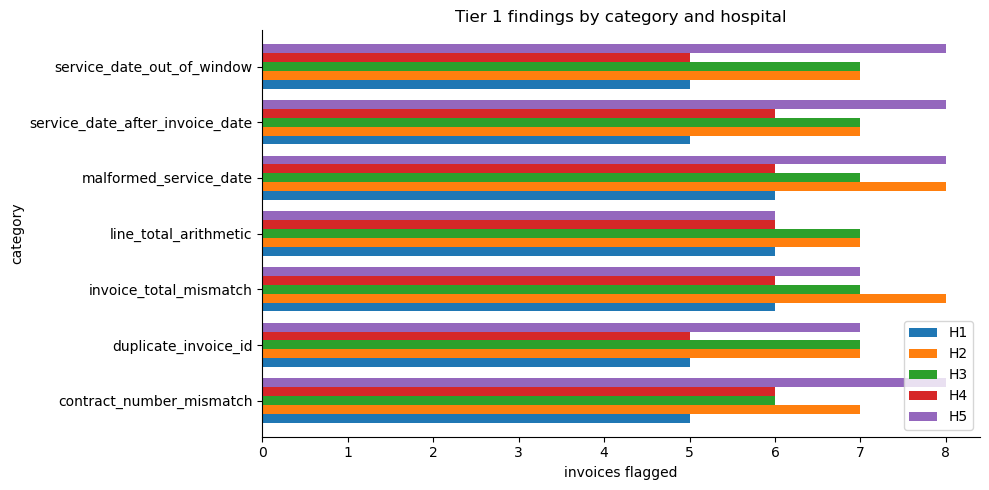

,H1,H2,H3,H4,H5
category,,,,,
contract_number_mismatch,5,7,6,6,8
duplicate_invoice_id,5,7,7,5,7
invoice_total_mismatch,6,8,7,6,7
line_total_arithmetic,6,7,7,6,6
malformed_service_date,6,8,7,6,8
service_date_after_invoice_date,5,7,7,6,8
service_date_out_of_window,5,7,7,5,8


In [27]:
wide = (pd.concat([f.assign(hospital=h) for h, f in tier1.items()])
          .pivot_table(index='category', columns='hospital',
                       values='invoice_id', aggfunc='nunique', fill_value=0))
wide.columns = [c.replace('hospital_', 'H') for c in wide.columns]

wide.plot(kind='barh', figsize=(10, 5), width=0.8)
plt.title('Tier 1 findings by category and hospital')
plt.xlabel('invoices flagged'); plt.legend(title='')
plt.tight_layout(); plt.show()
wide

> Every hospital shows the same seven categories at a similar rate. Nothing looks
> anomalous, which is mild evidence the checks travel correctly.

>> On hospital 1 these seven categories are 31 of the 58 errors — **53% of the total,**
>> **for zero contract reading and zero model calls.** That is the sequencing argument
>> the brief asks about: do the free thing first, everywhere, before spending budget
>> on the expensive thing anywhere.

---

## 🔎 What section 2️⃣ settled

| | |
|---|---|
| Precision on hospital 1 | **1.000** — no clean invoice was accused |
| Recall on hospital 1 | **0.534** — 31 of 58 |
| Categories fully solved | 7 of 18 |
| Contract rules read | none |
| Model calls | none |
| Cost | nothing |

The remaining eleven categories all need the same thing: knowing **what each service
should have cost**. That means reading the contract, which is section 3️⃣.

---

# 3️⃣ Reading the contracts

Section 2️⃣ found 31 of 58 errors without knowing a single price. The remaining
eleven categories all need the same thing: **what should this service have cost?**

So we have to read the contracts. Four of them are tables, and Python reads those.
One of them is paragraphs, and only a model can read that.

| | Format | Read by |
|---|---|---|
| hospital 1 | tables | regex |
| hospital 3 | tables, 3 documents, one amendment | regex |
| hospital 4 | tables | regex |
| hospital 5 | tables + a multiplier grid | regex |
| **hospital 2** | **76 clauses of prose** | **a language model** |

## Step 1 — One shape for all five

Every contract encodes the *same* pricing model. They just write it differently.
All four tabular contracts state the identical adjustment order, word for word:

> *(a) substitution of a bundled rate; (b) the facility multiplier; (c) the plan-tier
> multiplier; (d) any premium or uplift; and (e) any cumulative volume discount*

So we pour all five into one shape, and write the calculator **once**.

Plain dictionaries rather than classes, for one concrete reason: later we diff a
model's reading of a contract against the regex's reading, field by field. Dicts
make that a one-liner and are printable and JSON-serialisable for free.

### The modules this section uses

The notebook **is** the build: each file is written out here and then imported, so
running this notebook top to bottom reproduces the whole `src/` package. That is
what makes it work on a fresh Colab, which downloads the notebook and nothing else.

In [28]:
%%writefile src/config.py
"""Project-wide paths and constants.

Every monetary amount in this project is an integer number of cents.
There are no floats anywhere in the financial path — see `audit_engine`.
"""

from pathlib import Path

# Resolve the repository root from this file, so the code runs identically
# from a local clone and from a Colab checkout.
ROOT = Path(__file__).resolve().parents[1]
DATA = ROOT / "data"
CONTRACTS = DATA / "contracts"
INVOICES = DATA / "invoices"
LABELS = DATA / "labels"
REPORTS = ROOT / "reports"

HOSPITALS = ["hospital_1", "hospital_2", "hospital_3", "hospital_4", "hospital_5"]
DEV_HOSPITAL = "hospital_1"            # labelled; used for development only
SCORED_HOSPITALS = HOSPITALS[1:]       # hospitals 2-5 go in the submission

# The 18 error categories used by the hospital_1 label file. We reuse this
# vocabulary verbatim rather than inventing our own, so that per-category
# performance on the development set is directly reportable.
ERROR_CATEGORIES = [
    # --- detectable with no contract at all -------------------------------
    "line_total_arithmetic",
    "invoice_total_mismatch",
    "duplicate_invoice_id",
    "cross_invoice_duplicate",
    "service_date_after_invoice_date",
    "malformed_service_date",
    # --- need only the contract header ------------------------------------
    "service_date_out_of_window",
    "contract_number_mismatch",
    # --- need the rate table ----------------------------------------------
    "unit_price_mismatch",
    "wrong_unit_basis",
    "unknown_service",
    "daily_cap_exceeded",
    # --- need the contract rules ------------------------------------------
    "premium_incorrectly_applied",
    "premium_omitted",
    "volume_discount_incorrectly_applied",
    "volume_discount_omitted",
    "bundle_not_applied",
    "exclusion_window_violation",
]

# Unit bases as written in contracts -> as written on invoices.
UNIT_BASIS = {
    "per hour": "per_hour",
    "per day of service": "per_day",
    "per visit": "per_visit",
    "per procedure": "per_procedure",
    "per test": "per_test",
    "per item supplied": "per_item",
    "per night of occupancy": "per_night",
    "per unit dispensed": "per_unit_dispensed",
    "per hour, per item": "per_hour_per_item",   # compound basis; absent from hospital_1
}

Overwriting src/config.py


In [29]:
%%writefile src/money.py
"""Exact money.

Every contract states the same rounding convention (H1 s3.1, H2 s3.1, H5 s3.2):

    Where the application of a multiplier, premium or discount produces a
    fraction of a cent, the result shall be rounded to the nearest whole cent,
    with exact halves rounded away from zero ("half up"). Rounding is applied
    after each individual step of the calculation, not once at the end.

We implement "after each individual step" literally: `apply` rounds on every
call and the engine calls it once per step.

Measured, not assumed, and the two hospitals disagree:

  hospital 1   0 of   109 rate combinations differ between the two conventions
  hospital 5 115 of 1,062 rate combinations differ (10.83%)

Hospital 1 chains at most a premium and a discount, so the conventions are
indistinguishable there and the dev set cannot validate this choice at all.
Hospital 5 chains four multipliers — facility, plan tier, premium, discount —
and one rate in nine comes out a cent apart.

That makes the reading checkable: under step-rounding 99.3% of hospital 5 line
items reproduce their billed amount exactly. Under the alternative, roughly a
tenth of all rates would be off by a cent and would surface as spurious
`unit_price_mismatch` findings across the whole hospital. The agreement is the
evidence that the contract means what it says.

Decimal, never float. `0.1 + 0.2 != 0.3` is not an acceptable property for a
system that decides whether a hospital was overpaid.
"""

from decimal import Decimal, ROUND_HALF_UP

ONE = Decimal(1)


def half_up(value):
    """Round a Decimal to the nearest whole cent, halves away from zero."""
    return int(Decimal(value).quantize(Decimal(1), rounding=ROUND_HALF_UP))


def apply(cents, factor):
    """One adjustment step: multiply and round half-up immediately."""
    return half_up(Decimal(cents) * Decimal(factor))


def uplift(cents, fraction):
    """Apply a premium of `fraction` (0.20 -> +20%)."""
    return apply(cents, ONE + Decimal(fraction))


def discount(cents, fraction):
    """Apply a discount of `fraction` (0.10 -> -10%)."""
    return apply(cents, ONE - Decimal(fraction))

Overwriting src/money.py


In [30]:
%%writefile src/markdown_tables.py
"""Reading the tabular contracts.

Hospitals 1, 3, 4 and 5 state their rules in markdown tables under numbered
headings. Regex is the right tool for that: it is exact, it is fast, and a
reviewer can check it against the source document by eye. The LLM is reserved
for hospital 2, which has no tables at all.

`sections()` splits a document on its headings so that a table is always read
in the context of the clause that introduces it — this matters because several
tables share a column layout but mean different things.
"""

import re
from decimal import Decimal

_HEADING = re.compile(r"^#{2,3}\s+(.*)$", re.M)


def sections(text):
    """{heading: body} for every '##' or '###' heading in the document."""
    marks = [(m.start(), m.group(1).strip()) for m in _HEADING.finditer(text)]
    out = {}
    for i, (pos, title) in enumerate(marks):
        end = marks[i + 1][0] if i + 1 < len(marks) else len(text)
        out[title] = text[pos:end]
    return out


def table(body):
    """Every data row of the markdown table(s) in `body`, as lists of cells.

    The header row and the `|---|` separator are dropped. A cell of '—' (the
    em dash the contracts use for "not applicable") becomes None.
    """
    rows, header = [], None
    for line in body.splitlines():
        line = line.strip()
        if not line.startswith("|"):
            continue
        if set(line) <= set("|-: "):
            continue
        cells = [c.strip() for c in line.strip("|").split("|")]
        if header is None:
            header = cells                    # first row of a table is its header
            continue
        rows.append([None if c in {"—", "-", ""} else c for c in cells])
    return rows, header


def columns(rows, header, *names):
    """Pull named columns out of a table by header text, not by position.

    Hospital 1's bundle table is `Service A | Service B | Rate A | Rate B`; hospital 5's
    is `Service A | Rate A | Service B | Rate B`. Reading by position silently swaps a
    service name for a price. Reading by header does not, and fails loudly if a column
    is missing.

    A name may list alternatives separated by `|`, because the five contracts label the
    same column differently -- "Not billable within" and "Window" both mean the length
    of an exclusion window. The first alternative that matches wins.
    """
    idx = []
    for want in names:
        chosen = None
        for alt in want.split("|"):
            matches = [i for i, h in enumerate(header) if alt.lower() in h.lower()]
            if matches:
                chosen = matches[0]
                break
        if chosen is None:
            raise KeyError(f"none of {want.split('|')!r} found in {header}")
        idx.append(chosen)
    return [[r[i] for i in idx] for r in rows]


def decimal_val(text):
    """'1.08' -> Decimal('1.08'). Via str, never via float."""
    return Decimal(str(text).strip())


def find(secs, *keywords):
    """The body of the first section whose heading contains all keywords."""
    for title, body in secs.items():
        low = title.lower()
        if all(k.lower() in low for k in keywords):
            return body
    return None


def cents(text):
    """'GBP 1,301.25' -> 130125. Exact: parsed as Decimal, never as float."""
    digits = re.sub(r"[^0-9.]", "", text)
    return int((Decimal(digits) * 100).to_integral_value())


def fraction(text):
    """'+20%' -> 0.20, '12%' -> 0.12. Returned as Decimal for exact arithmetic."""
    return Decimal(re.sub(r"[^0-9.]", "", text)) / Decimal(100)


def quantity(text):
    """'6 days', 'more than 10 items', '8 visits' -> 6, 10, 8."""
    m = re.search(r"(\d+)", text)
    return int(m.group(1)) if m else None

Overwriting src/markdown_tables.py


In [31]:
%%writefile src/contract_spec.py
"""The one shape every contract turns into.

All five contracts encode the *same* pricing model. Hospital 1 states it in tables,
hospital 2 dissolves it into prose, hospital 3 splits it across three documents and
reprices part of it halfway through the term, hospital 5 adds a facility x plan-tier
grid. What differs is presentation, not meaning: H1 s3.2, H2 s3.2, H4 s4.1 and H5 s3.1
all state the identical adjustment order.

    (a) substitute a bundled rate
    (b) facility multiplier
    (c) plan-tier multiplier
    (d) premium or uplift
    (e) cumulative volume discount

with half-up rounding to the cent *after each step*.

So the engine is written once against this shape, and the per-hospital work is
producing one of these dicts -- by regex where the contract is tabular, by model where
it is prose. Plain dicts rather than classes, so a spec is trivially printable,
comparable and JSON-serialisable: we diff a model's extraction against a regex-built
spec field by field, and dicts make that a one-liner.

`provenance` records where each rule came from, so any extracted rule can be traced
back to the clause that produced it.
"""


def new_rate(cents, valid_from=None, valid_to=None):
    """A rate, optionally bounded in time.

    Hospital 3's Amendment No. 1 substitutes rates from 1 January 2025 *by service
    date*, so one service can hold several non-overlapping rates.
    """
    return {"cents": int(cents), "valid_from": valid_from, "valid_to": valid_to}


def rate_covers(rate, on):
    """Is this rate in force on the given date?"""
    if on is None:
        return rate["valid_from"] is None and rate["valid_to"] is None
    return ((rate["valid_from"] is None or on >= rate["valid_from"])
            and (rate["valid_to"] is None or on <= rate["valid_to"]))


def rate_on(service, service_date):
    """The contracted rate in force for a service on a date, or None."""
    for rate in service["rates"]:
        if rate_covers(rate, service_date):
            return rate["cents"]
    # A rate with no date bounds always applies; fall back to it.
    for rate in service["rates"]:
        if rate["valid_from"] is None and rate["valid_to"] is None:
            return rate["cents"]
    return None


def new_service(name, unit_basis, rates, daily_cap=None):
    return {"name": name, "unit_basis": unit_basis, "rates": rates, "daily_cap": daily_cap}


def new_spec(hospital, contract_number, effective_from, effective_to):
    """An empty contract spec, ready for a compiler to fill."""
    return {
        "hospital": hospital,
        "contract_number": contract_number,
        "effective_from": effective_from,
        "effective_to": effective_to,
        "services": {},               # name -> service dict
        "threshold_premiums": {},     # name -> (threshold_qty, uplift_fraction)
        "nbd_uplifts": {},            # name -> uplift_fraction
        "volume_discounts": {},       # name -> [(threshold, fraction), ...] deepest first
        "bundles": [],                # [(service_a, service_b, rate_a, rate_b), ...]
        "exclusions": [],             # [(service, days, other_service), ...]
        "facility_multipliers": {},   # name -> {facility_code: multiplier}
        "tier_multipliers": {},       # name -> {plan_tier: multiplier}
        "provenance": {},             # rule family -> where it came from
        "warnings": [],               # anything we could not read cleanly
    }


def bundle_partner(spec, service):
    """The service that must co-occur for a bundled rate, and the substituted rate."""
    for a, b, rate_a, rate_b in spec["bundles"]:
        if service == a:
            return b, rate_a
        if service == b:
            return a, rate_b
    return None, None


def summarise(spec):
    """One row describing a compiled spec, for eyeballing that it read correctly."""
    return {
        "hospital": spec["hospital"],
        "contract": spec["contract_number"],
        "services": len(spec["services"]),
        "priced_periods": sum(len(s["rates"]) for s in spec["services"].values()),
        "daily_caps": sum(s["daily_cap"] is not None for s in spec["services"].values()),
        "threshold_premiums": len(spec["threshold_premiums"]),
        "nbd_uplifts": len(spec["nbd_uplifts"]),
        "volume_discounts": len(spec["volume_discounts"]),
        "bundles": len(spec["bundles"]),
        "exclusions": len(spec["exclusions"]),
        "facility_multipliers": len(spec["facility_multipliers"]),
        "tier_multipliers": len(spec["tier_multipliers"]),
        "warnings": len(spec["warnings"]),
    }

Overwriting src/contract_spec.py


In [32]:
%%writefile src/compile_contract.py
"""Turning a contract document into a spec.

One compiler per hospital, sharing the readers in `markdown_tables`. Four of the five
contracts are tables, so regex is the honest tool: exact, fast, and checkable by eye
against the source. Hospital 2 has no tables at all and is handled separately by
`llm_extract`.

Each compiler is deliberately strict. A service named in a premium, discount, bundle
or exclusion table that does not appear in the rate schedule is recorded as a warning
rather than dropped, because a silently dropped rule misprices every invoice touching
that service and does so invisibly.
"""

import glob
from datetime import date

from src.config import UNIT_BASIS
from src.contract_header import read_header
from src.contract_spec import new_spec, new_service, new_rate
from src.markdown_tables import (sections, table, find, columns, cents, fraction,
                                 quantity, decimal_val)


def _check_known(spec, names, where):
    """Record any service named by a rule table that the rate schedule lacks."""
    for n in names:
        if n not in spec["services"]:
            spec["warnings"].append(f"{where}: unknown service {n!r} not in rate schedule")


def _read_rule_tables(spec, secs, *, premiums, nbd, discounts, bundles, exclusions,
                      caps=None):
    """The rule families every contract states, in whatever section it states them.

    Columns are matched by header text rather than by position: hospital 1's bundle
    table is `Service A | Service B | Rate A | Rate B` while hospital 5's is
    `Service A | Rate A | Service B | Rate B`. Reading by position would silently swap
    a service name for a price.
    """
    body = find(secs, *premiums)
    if body:
        rows, hdr = table(body)
        for name, threshold, uplift in columns(rows, hdr, "Service", "threshold|exceeds", "Uplift"):
            spec["threshold_premiums"][name] = (quantity(threshold), fraction(uplift))

    body = find(secs, *nbd)
    if body:
        rows, hdr = table(body)
        if rows:
            for name, uplift in columns(rows, hdr, "Service", "Uplift"):
                spec["nbd_uplifts"][name] = fraction(uplift)

    body = find(secs, *discounts)
    if body:
        rows, hdr = table(body)
        for name, threshold, disc in columns(rows, hdr, "Service", "utilisation|exceeds", "Discount"):
            spec["volume_discounts"].setdefault(name, []).append((quantity(threshold), fraction(disc)))
        for name in spec["volume_discounts"]:
            spec["volume_discounts"][name].sort(key=lambda t: -t[0])

    body = find(secs, *bundles)
    if body:
        rows, hdr = table(body)
        for a, b, ra, rb in columns(rows, hdr, "Service A", "Service B", "rate A", "rate B"):
            spec["bundles"].append((a, b, cents(ra), cents(rb)))

    body = find(secs, *exclusions)
    if body:
        rows, hdr = table(body)
        for svc, days, other in columns(rows, hdr, "Service", "within|Window", "Of this Service|Excluded by"):
            spec["exclusions"].append((svc, quantity(days), other))

    if caps:
        body = find(secs, *caps)
        if body:
            rows, hdr = table(body)
            for name, cap in columns(rows, hdr, "Service", "Maximum"):
                svc = spec["services"].get(name)
                q = quantity(cap)
                if svc is None:
                    spec["warnings"].append(f"caps: unknown service {name!r}")
                elif svc["daily_cap"] is None:
                    svc["daily_cap"] = q
                elif svc["daily_cap"] != q:
                    spec["warnings"].append(
                        f"caps: disagrees with rate schedule for {name!r}: {svc['daily_cap']} vs {q}")


def _validate(spec):
    _check_known(spec, spec["threshold_premiums"], "premiums")
    _check_known(spec, spec["nbd_uplifts"], "nbd uplifts")
    _check_known(spec, spec["volume_discounts"], "volume discounts")
    _check_known(spec, [n for t in spec["bundles"] for n in t[:2]], "bundles")
    _check_known(spec, [n for t in spec["exclusions"] for n in (t[0], t[2])], "exclusions")
    _check_known(spec, spec["facility_multipliers"], "facility multipliers")
    _check_known(spec, spec["tier_multipliers"], "tier multipliers")
    return spec


def _rate_schedule(spec, body, provenance):
    """A `Service | Unit basis | Rate | Daily cap` table."""
    rows, hdr = table(body)
    for row in columns(rows, hdr, "Service", "Unit basis", "Rate", "Daily cap"):
        name, basis, rate, cap = row
        spec["services"][name] = new_service(name, UNIT_BASIS[basis], [new_rate(cents(rate))],
                                             quantity(cap) if cap else None)
    spec["provenance"]["services"] = provenance


def _doc(data_root, hospital, stem):
    return open(f"{data_root}/contracts/{hospital}/{stem}.md").read()


# --------------------------------------------------------------------------
# hospital 1 - a single document, one table per rule family
# --------------------------------------------------------------------------

def compile_hospital_1(data_root, hospital="hospital_1"):
    hdr = read_header(data_root, hospital)
    secs = sections(_doc(data_root, hospital, "provider_services_agreement"))
    spec = new_spec(hospital, hdr["contract_number"], hdr["effective_from"], hdr["effective_to"])

    _rate_schedule(spec, find(secs, "Rate Schedule"), "s4 Rate Schedule")
    _read_rule_tables(spec, secs,
                      premiums=("Threshold Premiums",), nbd=("Non-Business-Day",),
                      discounts=("Volume Discounts",), bundles=("Bundled Services",),
                      exclusions=("Exclusion Windows",), caps=("Daily Quantity Caps",))
    spec["provenance"].update({"premiums": "s5", "nbd": "s6", "discounts": "s7",
                               "caps": "s4 + s8 (cross-checked)", "bundles": "s9",
                               "exclusions": "s10"})
    return _validate(spec)


# --------------------------------------------------------------------------
# hospital 3 - three documents, and an amendment that reprices by service date
# --------------------------------------------------------------------------

AMENDMENT_START = date(2025, 1, 1)

def compile_hospital_3(data_root, hospital="hospital_3"):
    """Base agreement + Appendix B rates + Amendment No. 1.

    The amendment "applies by Service Date. A line item whose Service Date falls on or
    after the effective date is priced under this Amendment; a line item whose Service
    Date falls before the effective date is priced under Appendix B. The date on which
    an invoice is issued is irrelevant." So an amended service carries two rates, each
    bounded in time, and the engine picks by service date.
    """
    hdr = read_header(data_root, hospital)
    base = sections(_doc(data_root, hospital, "base_agreement"))
    appendix = sections(_doc(data_root, hospital, "appendix_b_rate_schedule"))
    amendment = sections(_doc(data_root, hospital, "amendment_no_1"))

    spec = new_spec(hospital, hdr["contract_number"], hdr["effective_from"], hdr["effective_to"])
    _rate_schedule(spec, find(appendix, "B.1", "Rates"), "Appendix B.1 Rates")

    # A1.2 substitutes rates from 1 Jan 2025; both periods are stated explicitly.
    rows, h = table(find(amendment, "Substituted Rates"))
    for name, basis, before, after in columns(rows, h, "Service", "Unit basis",
                                              "to 31 December 2024", "from 1 January 2025"):
        if name not in spec["services"]:
            spec["warnings"].append(f"A1.2: substitutes unknown service {name!r}")
            continue
        spec["services"][name]["rates"] = [
            new_rate(cents(before), valid_to=AMENDMENT_START.replace(year=2024, month=12, day=31)),
            new_rate(cents(after), valid_from=AMENDMENT_START),
        ]

    # A1.3 adds services that "are not billable in respect of earlier Service Dates".
    rows, h = table(find(amendment, "Additional Services"))
    for name, basis, rate in columns(rows, h, "Service", "Unit basis", "Rate"):
        spec["services"][name] = new_service(name, UNIT_BASIS[basis],
                                             [new_rate(cents(rate), valid_from=AMENDMENT_START)])
    spec["provenance"]["amendment"] = "Amendment No. 1 A1.2/A1.3, applied by service date"

    _read_rule_tables(spec, base,
                      premiums=("Threshold Premiums",), nbd=("Non-Business-Day",),
                      discounts=("Volume Discounts",), bundles=("Bundled Services",),
                      exclusions=("Exclusion Windows",), caps=("Daily Quantity Caps",))
    spec["provenance"].update({"premiums": "base s4", "nbd": "base s5", "discounts": "base s6",
                               "caps": "Appendix B.1 + base s7", "bundles": "base s8",
                               "exclusions": "base s9"})
    return _validate(spec)


# --------------------------------------------------------------------------
# hospital 4 - single document; rates carry no cap column, caps are their own table
# --------------------------------------------------------------------------

def compile_hospital_4(data_root, hospital="hospital_4"):
    hdr = read_header(data_root, hospital)
    secs = sections(_doc(data_root, hospital, "conditional_reimbursement_agreement"))
    spec = new_spec(hospital, hdr["contract_number"], hdr["effective_from"], hdr["effective_to"])

    rows, h = table(find(secs, "Base Rates"))
    for name, basis, rate in columns(rows, h, "Service", "Unit basis", "Base rate"):
        spec["services"][name] = new_service(name, UNIT_BASIS[basis], [new_rate(cents(rate))])
    spec["provenance"]["services"] = "s3 Base Rates"

    _read_rule_tables(spec, secs,
                      premiums=("Threshold Premiums",), nbd=("Non-Business-Day",),
                      discounts=("Discounts",), bundles=("Bundled Delivery",),
                      exclusions=("Exclusion Windows",), caps=("Daily Quantity Limits",))
    spec["provenance"].update({"premiums": "s5", "caps": "s6", "bundles": "s7",
                               "discounts": "s8", "exclusions": "s9",
                               "nbd": "s10 (states 'None.')"})
    return _validate(spec)


# --------------------------------------------------------------------------
# hospital 5 - a facility x plan-tier multiplier grid over a base rate table
# --------------------------------------------------------------------------

def compile_hospital_5(data_root, hospital="hospital_5"):
    hdr = read_header(data_root, hospital)
    secs = sections(_doc(data_root, hospital, "network_reimbursement_agreement"))
    spec = new_spec(hospital, hdr["contract_number"], hdr["effective_from"], hdr["effective_to"])

    rows, h = table(find(secs, "Table 1"))
    for name, basis, rate, cap in columns(rows, h, "Service", "Unit basis", "Base rate", "Daily cap"):
        spec["services"][name] = new_service(name, UNIT_BASIS[basis], [new_rate(cents(rate))],
                                             quantity(cap) if cap else None)
    spec["provenance"]["services"] = "s4 Table 1"

    for title, key in (("Table 2", "facility_multipliers"), ("Table 3", "tier_multipliers")):
        rows, h = table(find(secs, title))
        names = h[1:]                       # the contract names its own columns
        for row in rows:
            spec[key][row[0]] = {k: decimal_val(v) for k, v in zip(names, row[1:])}
        spec["provenance"][key] = f"s4 {title}"

    _read_rule_tables(spec, secs,
                      premiums=("Threshold Premiums",), nbd=("Non-Business-Day",),
                      discounts=("Volume Discounts",), bundles=("Bundled Services",),
                      exclusions=("Exclusion Windows",))
    spec["provenance"].update({"premiums": "s5", "nbd": "s6", "bundles": "s7",
                               "discounts": "s8", "exclusions": "s9"})
    return _validate(spec)


COMPILERS = {
    "hospital_1": compile_hospital_1,
    "hospital_3": compile_hospital_3,
    "hospital_4": compile_hospital_4,
    "hospital_5": compile_hospital_5,
}


def compile_contract(data_root, hospital):
    """Compile one hospital's contract. Hospital 2 is prose and needs `llm_extract`."""
    if hospital not in COMPILERS:
        raise NotImplementedError(f"{hospital} has no table-based compiler (it is prose)")
    return COMPILERS[hospital](data_root, hospital)

Overwriting src/compile_contract.py


In [33]:
%%writefile src/spec_diff.py
"""Marking one contract reading against another.

This is the measuring stick, and it is built *before* any model runs. That order
matters: a model's output is text, and text always looks plausible. Without a scorer
you cannot tell a correct extraction from a confident fabrication.

We get the correct answers for free. Hospitals 1, 3, 4 and 5 state their rules in
tables, so `compile_contract` already produces a spec we know is right. Hand the same
contract text to a model, diff its spec against the regex one field by field, and you
have a labelled extraction benchmark that cost nothing to produce.

Three kinds of mistake are counted separately, because they cost different amounts:

    missed       a rule in the contract the model did not report.
                 Leaves a visible gap: the engine cannot price that service.

    wrong        a rule reported with the wrong value.
                 Prices every invoice touching that service incorrectly.

    hallucinated a rule the model reported that is not in the contract at all.
                 The most expensive: a confident number with no source. This is the
                 failure the brief singles out, so it is reported on its own.

Money is compared exactly. A rate of 10620 against a true 10625 is not "close",
it is wrong, and partial credit would hide exactly the errors we care about.
"""

import pandas as pd

RULE_FAMILIES = ["threshold_premiums", "nbd_uplifts", "volume_discounts",
                 "bundles", "exclusions", "facility_multipliers", "tier_multipliers"]


def _prf(tp, fp, fn):
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return round(p, 4), round(r, 4), round(f, 4)


def _rule_items(spec, family):
    """A rule family flattened to a comparable set of tuples."""
    value = spec.get(family)
    if family in ("bundles", "exclusions"):
        return {tuple(t) for t in value}
    if family in ("facility_multipliers", "tier_multipliers"):
        return {(name, k, str(v)) for name, cols in value.items() for k, v in cols.items()}
    if family == "volume_discounts":
        return {(name, t, str(f)) for name, tiers in value.items() for t, f in tiers}
    if family == "threshold_premiums":
        return {(name, t, str(f)) for name, (t, f) in value.items()}
    return {(name, str(f)) for name, f in value.items()}          # nbd_uplifts


def compare_specs(gold, pred):
    """Score one spec against another. Returns a flat dict of metrics."""
    g_names, p_names = set(gold["services"]), set(pred["services"])
    shared = g_names & p_names
    s_p, s_r, s_f = _prf(len(shared), len(p_names - g_names), len(g_names - p_names))

    rate_ok = basis_ok = cap_ok = 0
    for name in shared:
        g, p = gold["services"][name], pred["services"][name]
        if sorted((r["cents"], r["valid_from"], r["valid_to"]) for r in g["rates"]) == \
           sorted((r["cents"], r["valid_from"], r["valid_to"]) for r in p["rates"]):
            rate_ok += 1
        if g["unit_basis"] == p["unit_basis"]:
            basis_ok += 1
        if g["daily_cap"] == p["daily_cap"]:
            cap_ok += 1

    out = {
        "gold_services": len(g_names),
        "found_services": len(shared),
        "missed_services": len(g_names - p_names),
        "hallucinated_services": len(p_names - g_names),
        "service_precision": s_p, "service_recall": s_r, "service_f1": s_f,
        "rate_exact": round(rate_ok / len(shared), 4) if shared else 0.0,
        "unit_basis_exact": round(basis_ok / len(shared), 4) if shared else 0.0,
        "daily_cap_exact": round(cap_ok / len(shared), 4) if shared else 0.0,
    }

    hallucinated_rules = 0
    for family in RULE_FAMILIES:
        g_items, p_items = _rule_items(gold, family), _rule_items(pred, family)
        tp = len(g_items & p_items)
        fp = len(p_items - g_items)
        fn = len(g_items - p_items)
        hallucinated_rules += fp
        p_, r_, f_ = _prf(tp, fp, fn)
        out[f"{family}_f1"] = f_
        out[f"{family}_support"] = len(g_items)

    out["hallucinated_rules"] = hallucinated_rules
    out["hallucination_rate"] = round(
        (out["hallucinated_services"] + hallucinated_rules)
        / max(1, len(g_names) + sum(len(_rule_items(gold, f)) for f in RULE_FAMILIES)), 4)
    return out


def diff_report(gold, pred, limit=10):
    """Human-readable list of what differs, for error analysis."""
    rows = []
    g_names, p_names = set(gold["services"]), set(pred["services"])
    for name in sorted(g_names - p_names)[:limit]:
        rows.append({"kind": "missed_service", "item": name, "gold": "", "predicted": ""})
    for name in sorted(p_names - g_names)[:limit]:
        rows.append({"kind": "HALLUCINATED_service", "item": name, "gold": "", "predicted": ""})
    for name in sorted(g_names & p_names):
        g, p = gold["services"][name], pred["services"][name]
        gr = sorted(r["cents"] for r in g["rates"])
        pr = sorted(r["cents"] for r in p["rates"])
        if gr != pr:
            rows.append({"kind": "wrong_rate", "item": name, "gold": gr, "predicted": pr})
        if g["unit_basis"] != p["unit_basis"]:
            rows.append({"kind": "wrong_unit_basis", "item": name,
                         "gold": g["unit_basis"], "predicted": p["unit_basis"]})
        if g["daily_cap"] != p["daily_cap"]:
            rows.append({"kind": "wrong_daily_cap", "item": name,
                         "gold": g["daily_cap"], "predicted": p["daily_cap"]})
    for family in RULE_FAMILIES:
        g_items, p_items = _rule_items(gold, family), _rule_items(pred, family)
        for item in sorted(g_items - p_items, key=str)[:limit]:
            rows.append({"kind": f"missed_{family}", "item": str(item), "gold": "", "predicted": ""})
        for item in sorted(p_items - g_items, key=str)[:limit]:
            rows.append({"kind": f"HALLUCINATED_{family}", "item": str(item),
                         "gold": "", "predicted": ""})
    return pd.DataFrame(rows, columns=["kind", "item", "gold", "predicted"])

Overwriting src/spec_diff.py


In [34]:
import src.contract_spec as cs
import src.compile_contract as cc
import src.spec_diff as sd
importlib.reload(cs); importlib.reload(cc); importlib.reload(sd)

spec = cc.compile_contract(DATA, 'hospital_1')

print('THE SHAPE:')
for key, value in spec.items():
    kind = type(value).__name__
    size = len(value) if hasattr(value, '__len__') else value
    print(f'  {key:22s} {kind:6s} {size}')

THE SHAPE:
  hospital               str    10
  contract_number        str    16
  effective_from         date   2024-01-01
  effective_to           date   2025-12-31
  services               dict   108
  threshold_premiums     dict   9
  nbd_uplifts            dict   7
  volume_discounts       dict   7
  bundles                list   3
  exclusions             list   6
  facility_multipliers   dict   0
  tier_multipliers       dict   0
  provenance             dict   7
  warnings               list   0


In [35]:
# One service, in full.
name = 'Standard Otolaryngologic Radiotherapy Fraction'
print(name)
print('  ', spec['services'][name])
print()
print('its volume discounts:', spec['volume_discounts'][name])
print()
print('provenance — where every rule came from:')
for k, v in spec['provenance'].items():
    print(f'  {k:12s} {v}')

Standard Otolaryngologic Radiotherapy Fraction
   {'name': 'Standard Otolaryngologic Radiotherapy Fraction', 'unit_basis': 'per_item', 'rates': [{'cents': 25250, 'valid_from': None, 'valid_to': None}], 'daily_cap': None}

its volume discounts: [(180, Decimal('0.3')), (60, Decimal('0.12'))]

provenance — where every rule came from:
  services     s4 Rate Schedule
  premiums     s5
  nbd          s6
  discounts    s7
  caps         s4 + s8 (cross-checked)
  bundles      s9
  exclusions   s10


> A service is a plain dict: a unit basis, a list of rates, and a daily cap.

>> `provenance` records the section each rule family came from. When a model extracts
>> a rule later, we can always trace it back to the clause that produced it — which is
>> the difference between an auditable system and a black box.

## Step 2 — Compile all four tabular contracts

In [36]:
specs = {}
rows = []
for h in ['hospital_1', 'hospital_3', 'hospital_4', 'hospital_5']:
    specs[h] = cc.compile_contract(DATA, h)
    rows.append(cs.summarise(specs[h]))
pd.DataFrame(rows)

,hospital,contract,services,priced_periods,daily_caps,threshold_premiums,nbd_uplifts,volume_discounts,bundles,exclusions,facility_multipliers,tier_multipliers,warnings
0,hospital_1,INS-H1-2024-0417,108,108,7,9,7,7,3,6,0,0,0
1,hospital_3,INS-H3-2024-0562,120,127,12,14,12,12,5,10,0,0,0
2,hospital_4,INS-H4-2024-2049,98,98,18,18,0,3,7,15,0,0,0
3,hospital_5,INS-H5-2024-0731,84,84,9,10,9,9,3,7,84,84,0


> All four compile with **zero warnings**. A warning here would mean a rule table
> named a service the rate schedule does not contain — a silent mispricing.

>> Look at hospital 3: **120 services but 127 priced periods.** Its Amendment No. 1
>> reprices seven services from 1 January 2025, *by service date rather than invoice
>> date*, so those seven carry two rates each and the engine picks by when the
>> treatment happened. Look at hospital 4: **zero** non-business-day uplifts, because
>> its section 10 literally reads `_None._`. That is correct, not a parse failure.

In [37]:
# Hospital 3's amendment, visible in the data
amended = {n: s for n, s in specs['hospital_3']['services'].items() if len(s['rates']) > 1}
print(f'services repriced by the amendment: {len(amended)}')
print()
for n, s in list(amended.items())[:4]:
    before = [r for r in s['rates'] if r['valid_to']][0]
    after  = [r for r in s['rates'] if r['valid_from']][0]
    print(f"{n[:46]:46s} {before['cents']:>7} -> {after['cents']:>7} from {after['valid_from']}")

services repriced by the amendment: 7

Ambulatory Otolaryngologic Imaging Interpretat  182625 ->  208200 from 2025-01-01
Assisted Urologic Endoscopic Procedure           94250 ->  111225 from 2025-01-01
Bedside Neurological Radiotherapy Fraction        2575 ->    3050 from 2025-01-01
Intensive Infectious Anaesthesia Administratio  294675 ->  312350 from 2025-01-01


> Seven services, two prices each, switching on 1 January 2025 **by service date**.

>> The amendment says it plainly: *"The date on which an invoice is issued is
>> irrelevant for this purpose."* An invoice raised in March 2025 for treatment given
>> in December 2024 is priced at the old rate. That is the kind of clause that is easy
>> to read past and expensive to get wrong.

## Step 3 — Build the exam, before any model runs

This is the step that matters most, and it is easy to skip.

A model's output is **text**. Text always looks plausible — well formatted,
confident, fluent. By reading it you genuinely cannot tell a correct extraction from
an invented one.

So we build the marking scheme first. And we get the answers **free**: hospitals 3, 4
and 5 are tables, so we already know every correct value. Hand a model the same
contract text, diff the two readings field by field, and that is a labelled
benchmark that cost nothing.

In [38]:
# A perfect answer must score perfectly. The easy test.
perfect = sd.compare_specs(specs['hospital_5'], specs['hospital_5'])
print('a spec marked against itself:')
for k, v in perfect.items():
    if 'support' not in k:
        print(f'  {k:26s} {v}')

a spec marked against itself:
  gold_services              84
  found_services             84
  missed_services            0
  hallucinated_services      0
  service_precision          1.0
  service_recall             1.0
  service_f1                 1.0
  rate_exact                 1.0
  unit_basis_exact           1.0
  daily_cap_exact            1.0
  threshold_premiums_f1      1.0
  nbd_uplifts_f1             1.0
  volume_discounts_f1        1.0
  bundles_f1                 1.0
  exclusions_f1              1.0
  facility_multipliers_f1    1.0
  tier_multipliers_f1        1.0
  hallucinated_rules         0
  hallucination_rate         0.0


In [39]:
# The test that actually matters: break it on purpose, in seven known ways,
# and check the marker finds exactly seven.
import copy
from decimal import Decimal

gold = specs['hospital_5']
bad = copy.deepcopy(gold)
names = sorted(bad['services'])

del bad['services'][names[0]]                                            # 1 missed
bad['services']['Invented Cardiac Nonsense'] = cs.new_service(           # 2 invented
    'Invented Cardiac Nonsense', 'per_visit', [cs.new_rate(12345)])
bad['services'][names[5]]['rates'][0]['cents'] += 5                      # 3 rate off by 5c
bad['services'][names[6]]['unit_basis'] = 'per_visit'                    # 4 wrong basis
bad['services'][names[7]]['daily_cap'] = 99                              # 5 wrong cap
bad['threshold_premiums']['Invented Cardiac Nonsense'] = (5, Decimal('0.25'))  # 6 invented rule
bad['nbd_uplifts'].pop(sorted(bad['nbd_uplifts'])[0])                    # 7 missed rule

print(sd.diff_report(gold, bad).to_string(index=False))

                           kind                                                    item     gold predicted
                 missed_service                    Advanced Cardiac Ventilation Support                   
           HALLUCINATED_service                               Invented Cardiac Nonsense                   
                     wrong_rate          Ambulatory Paediatric Isolation Room Occupancy [126525]  [126530]
               wrong_unit_basis                    Assisted Cardiac Ventilation Support  per_day per_visit
                wrong_daily_cap                  Assisted Hepatic Physiotherapy Session       12        99
HALLUCINATED_threshold_premiums                ('Invented Cardiac Nonsense', 5, '0.25')                   
             missed_nbd_uplifts ('Ambulatory Metabolic Imaging Interpretation', '0.15')                   


> Seven faults injected, seven found, each named correctly — including the rate that
> was wrong by **five cents**.

>> Money is compared exactly. `126530` against a true `126525` scores zero, not
>> "close". Partial credit would hide precisely the errors we are hunting.

>> Three kinds of mistake are counted separately because they cost different amounts:
>> **missed** leaves a visible gap, **wrong** misprices every invoice touching that
>> service, and **hallucinated** is a confident number with no source. The brief
>> singles out the third, so it gets its own metric rather than being averaged away.

## Step 4 — Hospital 2 has no tables

Now the one that needs a model. Here is what we are up against.

In [40]:
h2 = open(f'{DATA}/contracts/hospital_2/master_services_agreement.md').read()

clauses = re.findall(r'^\d+\.\d+ In respect of.*$', h2, flags=re.M)
print(f'characters        : {len(h2):,}')
print(f'approx tokens     : {len(h2)//4:,}')
print(f'markdown tables   : {len([l for l in h2.splitlines() if l.strip().startswith("|")])}')
print(f'rate clauses      : {len(clauses)}')
print()
print('ONE CLAUSE, IN FULL:')
print(textwrap.fill(clauses[1], 78))

characters        : 148,145
approx tokens     : 37,036
markdown tables   : 0
rate clauses      : 76

ONE CLAUSE, IN FULL:
4.2 In respect of Assisted Infectious Telemetry Monitoring, the Provider shall
invoice the Payer at the rate of GBP 106.25 per hour, per item. The Provider
shall be able to demonstrate, from its clinical record, the quantity billed
for this Service on any Service Day. Where an invoice presents this Service on
a unit basis other than the one stated in this clause, the line item shall be
treated as incorrectly presented and shall be returned to the Provider. The
description applied by the Provider on any invoice shall not of itself vary
the rate applicable to this Service; the rate follows the Service actually
delivered. The Provider shall present this Service on its invoices under a
description sufficient to identify it as Assisted Infectious Telemetry
Monitoring, and shall not present it under a description that identifies a
different contracted Service.


> 120 words. Three usable facts: the service name, `10625`, and `per_hour_per_item`.
> Everything else — *"shall be able to demonstrate from its clinical record"*,
> *"shall be returned to the Provider"* — is legal padding.

>> There are **76 of these**, spread across 35 articles. No regex will read them
>> reliably, and that is the entire reason a language model appears in this project.

## Step 5 — Cut it into pieces a model can hold

Hospital 2 is 37,036 tokens. Qwen2.5-7B's context window is **32,768**.

So the contract does not fit, and chunking is *forced* — by the smallest model in the
lineup, which is also the only one that can run entirely on our own machine.

We cut it **structurally**, using the contract's own headings, not semantically.

In [41]:
%%writefile src/chunking.py
"""Splitting a contract into pieces a model can read.

Hospital 2 is 37,036 tokens; Qwen2.5-7B's context window is 32,768. The contract
does not fit, so chunking is forced rather than chosen -- by the smallest model in
the lineup, which is exactly the model that proves the pipeline can run air-gapped.

We chunk structurally, not semantically. The contract's own headings say which
articles carry rates: 13 titled 'Contracted Services (N Group)' hold all 76 rate
clauses, and 22 boilerplate articles hold none. A one-line filter on the heading
drops 49% of the document with no recall risk, because the heading states what the
section is. An embedding index would return the top-k most similar chunks; we need
all thirteen, and top-k is the wrong tool when you need everything.

Convention articles are pulled out separately rather than dropped silently. The task
description warns of a definitions section that quietly changes how days are
counted, and hospital 2 does exactly that.
"""

import re

from src.markdown_tables import sections

RATE_ARTICLE = 'Contracted Services'
CLAUSE = re.compile(r'^\d+\.\d+ In respect of', re.M)
CONVENTION_MARKERS = ['Definitions', 'Calculation Conventions', 'Interpretation']


def rate_chunks(text, marker=RATE_ARTICLE):
    """The articles that carry rates, as [{title, text, n_clauses}].

    `n_clauses` is how many Services the article should yield, counted by regex, so a
    model returning fewer has demonstrably missed some without needing a gold answer.
    """
    return [{'title': title, 'text': body.strip(), 'n_clauses': len(CLAUSE.findall(body))}
            for title, body in sections(text).items()
            if marker.lower() in title.lower()]


def dropped_chunks(text, marker=RATE_ARTICLE):
    """What the filter threw away, so it can be audited rather than trusted."""
    return [{'title': title, 'chars': len(body)}
            for title, body in sections(text).items()
            if marker.lower() not in title.lower()]


def chunk_stats(text, marker=RATE_ARTICLE):
    """What the filter kept and what it dropped."""
    kept, dropped = rate_chunks(text, marker), dropped_chunks(text, marker)
    kept_chars = sum(len(c['text']) for c in kept)
    dropped_chars = sum(c['chars'] for c in dropped)
    return {'articles_kept': len(kept),
            'articles_dropped': len(dropped),
            'clauses_expected': sum(c['n_clauses'] for c in kept),
            'tokens_kept': kept_chars // 4,
            'tokens_dropped': dropped_chars // 4,
            'fraction_dropped': round(dropped_chars / (kept_chars + dropped_chars), 3),
            'largest_chunk_tokens': max((len(c['text']) // 4 for c in kept), default=0)}


def convention_chunks(text, markers=None):
    """Articles that define terms or calculation order rather than rates."""
    markers = markers or CONVENTION_MARKERS
    return [{'title': title, 'text': body.strip()}
            for title, body in sections(text).items()
            if any(m.lower() in title.lower() for m in markers)]


def convention_checklist(text):
    """The conventions the engine depends on, quoted from the contract itself.

    Every one of these is implemented in `audit_engine`. Printing them beside the
    contract's own words is how we check the engine matches *this* hospital, rather
    than assuming all five contracts say the same thing.
    """
    body = ' '.join(c['text'] for c in convention_chunks(text))
    wanted = {
        'rounding': r'rounded to the nearest whole cent[^.]*',
        'rounding_step': r'Rounding is applied[^.]*',
        'adjustment_order': r'adjustments shall be applied to the base rate[^.]*',
        'service_day': r'"Service Day" means[^.]*',
        'business_day': r'"Business Day" means[^.]*',
        'cumulative': r'"Cumulative utilisation" means[^.]*',
    }
    out = {}
    for key, pattern in wanted.items():
        m = re.search(pattern, body)
        out[key] = m.group(0).strip() if m else None
    return out


# --------------------------------------------------------------------------
# Tabular contracts, batched
# --------------------------------------------------------------------------
# Hospital 3's rate schedule is 118 rows. Asking for all of them in one reply needs
# roughly 9,400 output tokens against a 4,096 limit, so the JSON would be truncated
# mid-object and the model would score zero for a reason unrelated to whether it can
# read. Batching keeps every reply comfortably inside the limit.
#
# This is a real constraint of the task rather than a workaround: output length is a
# harder ceiling than context length, and a system that ignores it fails silently on
# exactly the largest documents.

TABLE_BATCH = 15


def table_chunks(text, markers, batch_size=TABLE_BATCH, min_rows=3):
    """Rate tables from a tabular contract, split into batches of `batch_size` rows.

    Each batch keeps the table header so it remains readable on its own.
    """
    out = []
    for title, body in sections(text).items():
        if not any(m.lower() in title.lower() for m in markers):
            continue
        lines = [l for l in body.splitlines() if l.strip().startswith("|")]
        if len(lines) < min_rows + 2:
            continue
        header, rows = lines[:2], lines[2:]
        for start in range(0, len(rows), batch_size):
            batch = rows[start:start + batch_size]
            out.append({
                "title": f"{title} [rows {start + 1}-{start + len(batch)}]",
                "text": "\n".join(header + batch),
                "n_clauses": len(batch),
            })
    return out

Overwriting src/chunking.py


In [42]:
import src.chunking as ck
importlib.reload(ck)
stats = ck.chunk_stats(h2)
for k, v in stats.items():
    print(f'  {k:22s} {v}')
print()
for c in ck.rate_chunks(h2):
    print(f"  {c['title'][:50]:50s} {c['n_clauses']} clauses, {len(c['text'])//4:5d} tokens")

  articles_kept          13
  articles_dropped       22
  clauses_expected       76
  tokens_kept            18776
  tokens_dropped         18161
  fraction_dropped       0.492
  largest_chunk_tokens   1646

  Article IV — Contracted Services (One Group)       6 clauses,  1402 tokens
  Article VI — Contracted Services (Two Group)       6 clauses,  1481 tokens
  Article VIII — Contracted Services (Three Group)   6 clauses,  1495 tokens
  Article X — Contracted Services (Four Group)       6 clauses,  1506 tokens
  Article XII — Contracted Services (Five Group)     6 clauses,  1383 tokens
  Article XIV — Contracted Services (Six Group)      6 clauses,  1600 tokens
  Article XVI — Contracted Services (Seven Group)    6 clauses,  1441 tokens
  Article XVIII — Contracted Services (Eight Group)  6 clauses,  1403 tokens
  Article XX — Contracted Services (Nine Group)      6 clauses,  1441 tokens
  Article XXII — Contracted Services (Ten Group)     6 clauses,  1486 tokens
  Article XXIV — Contr

> **49.2% of the document dropped**, every one of the 76 rate clauses kept, and the
> largest piece is 1,646 tokens — comfortably inside every model's context, Qwen
> included.

>> This is the retrieval decision, made by measurement. We are not searching for the
>> rate clauses; the headings tell us which they are. And we need **all thirteen**, so
>> a top-k similarity search would be the wrong tool even if it were faster.

## Step 6 — The trap in the definitions

The task description warns:

> *"One is forty pages of prose with a definitions section that quietly changes how
> days are counted."*

So before extracting anything, compare hospital 2's conventions against hospital 1's.

In [43]:
h1 = open(f'{DATA}/contracts/hospital_1/provider_services_agreement.md').read()
c1, c2 = ck.convention_checklist(h1), ck.convention_checklist(h2)

for key in c2:
    same = (c1[key] or '').replace('taken', 'counted') == (c2[key] or '').replace('taken', 'counted')
    print(('  SAME     ' if same else '  DIFFERENT') + f'  {key}')
    if not same:
        print('      H1:', textwrap.fill(c1[key] or '(not stated)', 66, subsequent_indent=' ' * 10))
        print('      H2:', textwrap.fill(c2[key] or '(not stated)', 66, subsequent_indent=' ' * 10))

  SAME       rounding
  SAME       rounding_step
  SAME       adjustment_order
  DIFFERENT  service_day
      H1: "Service Day" means the calendar day recorded as the Service Date
          of the line item
      H2: "Service Day" means the period of twenty-four (24) hours
          commencing at 07:00 hours and concluding at 06:59 hours
          on the following calendar day
  DIFFERENT  business_day
      H1: "Business Day" means any Service Day other than a Saturday or a
          Sunday
      H2: "Business Day" means a Service Day which commences on a day other
          than a Saturday or a Sunday
  SAME       cumulative


> Rounding, adjustment order and cumulative utilisation are **word-for-word identical**.
> Only the day definitions differ — and they differ exactly where the brief said they
> would.

>> Hospital 2's Service Day runs 07:00 to 06:59, and a Business Day is one that
>> **commences** off a weekend. So a service delivered at 03:00 on a Monday belongs to
>> the Service Day that began on Sunday, and would attract the weekend uplift. Eight
>> hospital 2 services carry such an uplift.

In [44]:
li2 = dl.load_line_items(DATA, 'hospital_2')
print('does the data carry a time of day?')
print('  sample service_date values:', li2.service_date_raw.dropna().unique()[:4].tolist())
print()
sd_ = li2.service_date.dropna()
print(f'weekend service dates          : {(sd_.dt.weekday >= 5).sum():,} of {len(sd_):,}'
      f'  ({(sd_.dt.weekday >= 5).mean():.1%})')
shifted = (sd_ - pd.Timedelta(days=1)).dt.weekday
print(f'if every date shifted back one : {(shifted >= 5).sum():,}  ({(shifted >= 5).mean():.1%})')

does the data carry a time of day?
  sample service_date values: ['2023-01-15', '2023-02-03', '2023-02-07', '2023-09-19']

weekend service dates          : 3,942 of 14,352  (27.5%)
if every date shifted back one : 4,085  (28.5%)


> **Dates only. No times anywhere in the dataset.** So the 00:00–06:59 window cannot
> be identified, and the two readings cannot be distinguished from the data.

>> **Decision:** read the recorded date as the date the Service Day commenced —
>> identical in effect to hospital 1. The alternative requires assuming *every* service
>> began before 07:00, which would shift every date back a day and is implausible.

>> **And it is testable.** If the reading is wrong, only the eight uplift-bearing
>> services will mismatch, and only on dates next to weekends. That is a checkable
>> prediction rather than an assumption. Recorded in `reports/decision_log.md`.

## Step 7 — The prompt

This is the instruction we hand a model, and it is `v1` — the first version. Majed
asked for prompts as versioned files precisely so the iteration is visible.

It was written **after** reading what hospital 2 actually states, not before: 76 rate
clauses carrying 8 daily caps, 8 non-business-day uplifts, 9 threshold premiums, 8
volume-discount clauses, 6 bundles, and no exclusion windows at all.

In [45]:
%%writefile prompts/contract_extraction_v1.txt
You are a contract extraction component in an invoice auditing system.

You will be given ONE article from a healthcare reimbursement contract. The article
contains several numbered clauses. Each clause sets out the payment terms for exactly
one contracted Service.

Extract every Service in the article. Return STRICT JSON and nothing else.

## Output schema

{
  "services": [
    {
      "clause": "4.2",
      "service": "<exact Service name as written in the clause>",
      "unit_basis": "<one of the values listed below>",
      "rate_cents": <integer number of cents>,
      "daily_cap": <integer maximum Units per Patient per Service Day, or null>,
      "nbd_uplift_pct": <integer percent added when the Service Date is not a
                         Business Day, or null>,
      "threshold_premium": {"threshold": <integer>, "uplift_pct": <integer>} or null,
      "volume_discounts": [{"threshold": <integer>, "discount_pct": <integer>}],
      "bundle": {"partner_service": "<name>",
                 "this_rate_cents": <integer>,
                 "partner_rate_cents": <integer>} or null,
      "confidence": <number between 0 and 1>,
      "source_quote": "<the clause text that states the rate, verbatim, max 200 chars>"
    }
  ]
}

## unit_basis must be exactly one of

  per hour               -> "per_hour"
  per day of service     -> "per_day"
  per visit              -> "per_visit"
  per procedure          -> "per_procedure"
  per test               -> "per_test"
  per item supplied      -> "per_item"
  per night of occupancy -> "per_night"
  per unit dispensed     -> "per_unit_dispensed"
  per hour, per item     -> "per_hour_per_item"

## Rules

1. rate_cents is an INTEGER NUMBER OF CENTS. "GBP 106.25" is 10625. "GBP 1,648.25"
   is 164825. Never return pounds. Never return a decimal.

2. Numbers are written as words followed by digits, for example "twelve (12)" or
   "thirty percent (30%)". Use the digits.

3. Extract ONLY what the clause states. Do not infer, do not complete a pattern from
   other clauses, and do not carry a rule from one Service to another.

4. If a clause does not mention a rule, that field is null (or an empty list for
   volume_discounts). Absence is information. Do not guess a plausible value.

5. Most sentences in a clause are boilerplate about record-keeping, descriptions and
   consumables. They contain no extractable rule. Ignore them.

6. Set confidence below 0.7 for any Service where the clause is ambiguous, states a
   rule you are unsure how to represent, or uses wording you have not seen elsewhere.
   A low confidence costs a human a few minutes. A confident wrong rate silently
   misprices every invoice touching that Service.

7. source_quote must be copied verbatim from the clause. It is how a human checks you.

Return only the JSON object. No explanation, no markdown fence.

Overwriting prompts/contract_extraction_v1.txt


In [46]:
%%writefile prompts/contract_extraction_table_v1.txt
You are a contract extraction component in an invoice auditing system.

You will be given part of a rate table from a healthcare reimbursement contract, with
its header row. Each data row sets out the payment terms for exactly one contracted
Service.

Extract every row. Return STRICT JSON and nothing else.

## Output schema

{
  "services": [
    {
      "service": "<exact Service name from the row>",
      "unit_basis": "<one of the values listed below>",
      "rate_cents": <integer number of cents>,
      "daily_cap": <integer, or null if the cell is empty or shows a dash>,
      "confidence": <number between 0 and 1>,
      "source_quote": "<the row, verbatim>"
    }
  ]
}

## unit_basis must be exactly one of

  per hour               -> "per_hour"
  per day of service     -> "per_day"
  per visit              -> "per_visit"
  per procedure          -> "per_procedure"
  per test               -> "per_test"
  per item supplied      -> "per_item"
  per night of occupancy -> "per_night"
  per unit dispensed     -> "per_unit_dispensed"
  per hour, per item     -> "per_hour_per_item"

## Rules

1. rate_cents is an INTEGER NUMBER OF CENTS. "GBP 252.50" is 25250. "GBP 1,301.25" is
   130125. Never return pounds. Never return a decimal.

2. A daily cap cell containing an em dash, a hyphen, or nothing at all means there is
   no cap. Return null, not zero.

3. Extract ONLY the rows you were given. Do not continue the table, do not complete a
   pattern, and do not add a Service you were not shown.

4. Return one object per row. If you were given fifteen rows, return fifteen objects.

5. Set confidence below 0.7 for any row whose unit basis or rate you are unsure of. A
   low confidence costs a human a few minutes. A confident wrong rate silently
   misprices every invoice touching that Service.

6. source_quote must be the row copied verbatim. It is how a human checks you.

Return only the JSON object. No explanation, no markdown fence.

Overwriting prompts/contract_extraction_table_v1.txt


In [47]:
print(open(f'{PROJECT}/prompts/contract_extraction_v1.txt').read())

You are a contract extraction component in an invoice auditing system.

You will be given ONE article from a healthcare reimbursement contract. The article
contains several numbered clauses. Each clause sets out the payment terms for exactly
one contracted Service.

Extract every Service in the article. Return STRICT JSON and nothing else.

## Output schema

{
  "services": [
    {
      "clause": "4.2",
      "service": "<exact Service name as written in the clause>",
      "unit_basis": "<one of the values listed below>",
      "rate_cents": <integer number of cents>,
      "daily_cap": <integer maximum Units per Patient per Service Day, or null>,
      "nbd_uplift_pct": <integer percent added when the Service Date is not a
                         Business Day, or null>,
      "threshold_premium": {"threshold": <integer>, "uplift_pct": <integer>} or null,
      "volume_discounts": [{"threshold": <integer>, "discount_pct": <integer>}],
      "bundle": {"partner_service": "<name>",
  

> Four choices in there matter more than the rest:

> **Cents, as integers.** *"GBP 106.25 is 10625. Never return pounds. Never return a
> decimal."* A model that returns `106.25` breaks exact matching everywhere downstream.

> **Absence is information.** *"If a clause does not mention a rule, that field is null.
> Do not guess a plausible value."* Models complete patterns; five clauses in a row
> with a daily cap invites inventing a sixth.

> **A confidence per service**, with the reason stated: *"A low confidence costs a human
> a few minutes. A confident wrong rate silently misprices every invoice touching that
> Service."*

> **A verbatim quote** of the clause that produced each rule, so a human can check any
> row without rerunning anything.

>> Next: load Qwen2.5-7B from HuggingFace, wire up the three APIs, and mark all four
>> against the exam we just built.

---

# 4️⃣ Where a model earns its place

Everything so far has been deterministic Python, and it has taken us a long way:
three of the four scored hospitals fully audited, and 58 of 58 errors found on the
hospital we can check.

Hospital 2 is the one that cannot be done that way. 76 rate clauses, zero tables.

**Four models, one job:** read a clause, return the rate.

| Model | Weights | Runs where | Data leaves the machine |
|---|---|---|---|
| GPT-4o | closed | OpenAI's servers | yes |
| Kimi K2 | open | Moonshot's servers | yes |
| DeepSeek V4.1-Flash | open (MIT) | DeepSeek's servers | yes |
| **Qwen2.5-7B-Instruct** | open | **this notebook's GPU** | **no** |

That last row is the point. Qwen is the only one that demonstrates the pipeline can
run inside a hospital's own network. What that costs in accuracy is measured below
rather than assumed.

> ⚠️ **Requires a GPU runtime.** `Runtime → Change runtime type → T4 GPU`.
> Hosted models need `OPENROUTER_API_KEY` in Colab Secrets (🔑 icon, left sidebar).

In [ ]:
# openai 1.51 passes a `proxies` argument that httpx removed in 0.28, and Colab
# ships the newer httpx. Installing a current openai fixes it without downgrading
# a package the rest of the runtime depends on.
if IN_COLAB:
    !pip install -q --upgrade 'openai>=1.55.3'
    !pip install -q transformers==4.44.2 accelerate==0.34.2 bitsandbytes==0.43.3
    print()
    print('=' * 68)
    print('If this was the first install: Runtime > Restart session, then Run all.')
    print('=' * 68)

# torch is only needed for the local model. Its absence is reported rather than
# raised, so the notebook still runs end to end on a machine without a GPU.
try:
    import torch
    HAS_GPU = torch.cuda.is_available()
except ImportError:
    torch, HAS_GPU = None, False

import openai
print(f'openai        : {openai.__version__}')
print(f'GPU available : {HAS_GPU}')
if HAS_GPU:
    print(f'device        : {torch.cuda.get_device_name(0)}')
    print(f'memory        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('No GPU. Hosted models still run; Qwen does not.')
    print('On Colab: Runtime > Change runtime type > T4 GPU')

### The two modules the model comparison needs

In [49]:
%%writefile src/llm_client.py
"""One interface, four models.

Every model in the comparison is reached through the same `generate(prompt, text)`
call, so the bake-off changes one string and nothing else. Three are OpenAI-compatible
HTTP APIs and differ only in base URL and model id; the fourth runs locally on the
GPU through transformers.

Keys are never written into the notebook or this file. On Colab they come from the
Secrets panel, locally from the environment. A key pasted into a cell would be saved
into the .ipynb and pushed to GitHub, which is how keys leak.

The local model is the point of the exercise rather than a curiosity: it is the only
one that proves the pipeline can run with no data leaving the machine. What that costs
in accuracy is measured rather than assumed.
"""

import json
import os
import re
import time


def get_key(name):
    """Read an API key from Colab Secrets if present, else the environment."""
    try:
        from google.colab import userdata          # noqa: F401
        try:
            value = userdata.get(name)
            if value:
                return value
        except Exception:
            pass
    except ImportError:
        pass
    return os.environ.get(name)


# --------------------------------------------------------------------------
# Model registry
# --------------------------------------------------------------------------
# `via` is which credential to use. OpenRouter reaches all three hosted models with a
# single key, which is why it is the default; the direct routes are kept so the same
# code works if you hold separate accounts.

REGISTRY = {
    "gpt-4o": {
        "openrouter": ("https://openrouter.ai/api/v1", "openai/gpt-4o"),
        "direct":     ("https://api.openai.com/v1", "gpt-4o"),
        "direct_key": "OPENAI_API_KEY",
        "role": "closed API baseline",
    },
    "kimi-k2": {
        "openrouter": ("https://openrouter.ai/api/v1", "moonshotai/kimi-k2"),
        "direct":     ("https://api.moonshot.ai/v1", "kimi-k2-0711-preview"),
        "direct_key": "MOONSHOT_API_KEY",
        "role": "open weights, hosted",
    },
    "deepseek": {
        "openrouter": ("https://openrouter.ai/api/v1", "deepseek/deepseek-chat"),
        "direct":     ("https://api.deepseek.com/v1", "deepseek-chat"),
        "direct_key": "DEEPSEEK_API_KEY",
        "role": "open weights (MIT), hosted",
    },
}

LOCAL_MODEL = "Qwen/Qwen2.5-7B-Instruct"


class ApiModel:
    """An OpenAI-compatible chat endpoint. Works for all three hosted models."""

    def __init__(self, name, prefer="openrouter", temperature=0.0, max_tokens=4096):
        entry = REGISTRY[name]
        self.name = name
        self.temperature = temperature
        self.max_tokens = max_tokens

        key = get_key("OPENROUTER_API_KEY") if prefer == "openrouter" else None
        if key:
            self.base_url, self.model_id, self.via = (*entry["openrouter"], "openrouter")
        else:
            key = get_key(entry["direct_key"])
            self.base_url, self.model_id, self.via = (*entry["direct"], "direct")
        if not key:
            raise RuntimeError(
                f"no key for {name}. Set OPENROUTER_API_KEY, or {entry['direct_key']}, "
                f"in Colab Secrets (key icon, left sidebar) or the environment.")

        from openai import OpenAI
        self.client = OpenAI(api_key=key, base_url=self.base_url)

    def generate(self, system, user):
        """Return (text, usage). Temperature 0 so a rerun gives the same answer."""
        started = time.time()
        response = self.client.chat.completions.create(
            model=self.model_id,
            messages=[{"role": "system", "content": system},
                      {"role": "user", "content": user}],
            temperature=self.temperature,
            max_tokens=self.max_tokens,
        )
        usage = {
            "input_tokens": response.usage.prompt_tokens,
            "output_tokens": response.usage.completion_tokens,
            "seconds": round(time.time() - started, 2),
        }
        return response.choices[0].message.content, usage


class LocalModel:
    """Qwen2.5-7B-Instruct, loaded onto the Colab GPU in 4-bit.

    Nothing leaves the machine. This is the model that demonstrates the pipeline can
    run inside a hospital's own network, and the accuracy cost of that is what the
    comparison measures.
    """

    def __init__(self, model_id=LOCAL_MODEL, max_tokens=4096):
        import torch
        from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

        self.name = model_id.split("/")[-1]
        self.model_id = model_id
        self.via = "local"
        self.max_tokens = max_tokens

        quant = BitsAndBytesConfig(load_in_4bit=True,
                                   bnb_4bit_compute_dtype=torch.float16,
                                   bnb_4bit_quant_type="nf4",
                                   bnb_4bit_use_double_quant=True)
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_id, quantization_config=quant, device_map="auto", torch_dtype=torch.float16)
        self.model.eval()

    def generate(self, system, user):
        import torch
        started = time.time()
        messages = [{"role": "system", "content": system}, {"role": "user", "content": user}]
        text = self.tokenizer.apply_chat_template(messages, tokenize=False,
                                                  add_generation_prompt=True)
        inputs = self.tokenizer(text, return_tensors="pt").to(self.model.device)
        with torch.no_grad():
            out = self.model.generate(**inputs, max_new_tokens=self.max_tokens,
                                      do_sample=False,             # greedy: reproducible
                                      pad_token_id=self.tokenizer.eos_token_id)
        generated = out[0][inputs["input_ids"].shape[1]:]
        usage = {
            "input_tokens": int(inputs["input_ids"].shape[1]),
            "output_tokens": int(generated.shape[0]),
            "seconds": round(time.time() - started, 2),
        }
        return self.tokenizer.decode(generated, skip_special_tokens=True), usage


class StubModel:
    """A fake model that replays saved responses.

    Lets the whole pipeline be tested, and the notebook re-run, without a key, a GPU
    or a network call. Also makes the submission reproducible by anyone who clones the
    repository: the recorded responses are committed, so `submission.csv` can be
    rebuilt exactly without paying for inference.
    """

    def __init__(self, responses, name="stub"):
        self.responses = responses
        self.name = name
        self.via = "replay"
        self.calls = 0

    def generate(self, system, user):
        key = str(self.calls)
        self.calls += 1
        payload = self.responses.get(key, '{"services": []}')
        return payload, {"input_tokens": 0, "output_tokens": 0, "seconds": 0.0}


def parse_json(text):
    """Pull a JSON object out of a model's reply.

    Models wrap JSON in prose or markdown fences however firmly you ask them not to,
    and a parse failure must be a recorded outcome rather than a crash: "returned
    unparseable JSON" is itself a result worth reporting in the comparison.
    """
    text = text.strip()
    fence = re.search(r"```(?:json)?\s*(.*?)```", text, re.S)
    if fence:
        text = fence.group(1).strip()
    try:
        return json.loads(text), None
    except json.JSONDecodeError:
        pass
    start, end = text.find("{"), text.rfind("}")
    if start != -1 and end > start:
        try:
            return json.loads(text[start:end + 1]), None
        except json.JSONDecodeError as exc:
            return None, f"unparseable JSON: {exc}"
    return None, "no JSON object found in reply"

Overwriting src/llm_client.py


In [50]:
%%writefile src/llm_extract.py
"""Turning a model's reading of a contract into a spec the engine can price with.

The model returns JSON describing clauses. This module converts that into the same
dict shape `compile_contract` produces from tables, so hospital 2 flows through the
identical engine as the other four. Nothing downstream knows or cares which contract
was read by regex and which by a model.

Two principles.

**Nothing is trusted.** Every field is validated on the way in: the unit basis must be
one of nine known values, the rate must be a positive integer of cents, a bundle must
name a partner that exists. A field that fails validation is dropped and recorded as a
rejection, not silently coerced into something plausible.

**Everything is traceable.** Each extracted service carries the clause id, the model's
own confidence, and the verbatim quote it claims to have read the rate from. The quote
is checked against the source text, so a model that invents a supporting quote is
caught rather than believed.
"""

import re
from decimal import Decimal

from src.config import UNIT_BASIS
from src.contract_spec import new_spec, new_service, new_rate
from src.llm_client import parse_json

VALID_BASES = set(UNIT_BASIS.values())


def _as_int(value):
    if isinstance(value, bool) or value is None:
        return None
    if isinstance(value, int):
        return value
    if isinstance(value, float) and value.is_integer():
        return int(value)
    if isinstance(value, str):
        digits = re.sub(r"[^0-9]", "", value)
        return int(digits) if digits else None
    return None


def _pct(value):
    """20 or "20%" or 0.2 -> Decimal('0.20')."""
    n = _as_int(value) if not isinstance(value, float) else value
    if n is None:
        return None
    d = Decimal(str(n))
    return d / Decimal(100) if d > 1 else d


def validate_service(item, source_text=None):
    """Check one extracted service. Returns (record, [reasons rejected])."""
    problems = []
    name = (item.get("service") or "").strip()
    if not name:
        return None, ["no service name"]

    basis = (item.get("unit_basis") or "").strip()
    if basis not in VALID_BASES:
        problems.append(f"unit_basis {basis!r} not one of {sorted(VALID_BASES)}")

    rate = _as_int(item.get("rate_cents"))
    if rate is None or rate <= 0:
        problems.append(f"rate_cents {item.get('rate_cents')!r} is not a positive integer")

    # A model that invents a supporting quote is caught here.
    quote = (item.get("source_quote") or "").strip()
    if source_text and quote:
        normalise = lambda s: re.sub(r"\s+", " ", s).strip()
        if normalise(quote[:80]) not in normalise(source_text):
            problems.append("source_quote does not appear in the article")

    if problems:
        return None, problems

    record = {
        "service": name,
        "unit_basis": basis,
        "rate_cents": rate,
        "daily_cap": _as_int(item.get("daily_cap")),
        "nbd_uplift": _pct(item.get("nbd_uplift_pct")),
        "clause": item.get("clause"),
        "confidence": item.get("confidence"),
        "source_quote": quote,
    }

    prem = item.get("threshold_premium") or None
    if isinstance(prem, dict):
        t, u = _as_int(prem.get("threshold")), _pct(prem.get("uplift_pct"))
        if t and u:
            record["threshold_premium"] = (t, u)

    discounts = []
    for d in item.get("volume_discounts") or []:
        if isinstance(d, dict):
            t, f = _as_int(d.get("threshold")), _pct(d.get("discount_pct"))
            if t and f:
                discounts.append((t, f))
    record["volume_discounts"] = sorted(discounts, key=lambda t: -t[0])

    bundle = item.get("bundle") or None
    if isinstance(bundle, dict):
        partner = (bundle.get("partner_service") or "").strip()
        this_r = _as_int(bundle.get("this_rate_cents"))
        other_r = _as_int(bundle.get("partner_rate_cents"))
        if partner and this_r and other_r:
            record["bundle"] = (partner, this_r, other_r)

    return record, []


def build_spec(hospital, header, extracted, rejected=None):
    """Assemble validated records into the same shape `compile_contract` returns."""
    spec = new_spec(hospital, header["contract_number"],
                    header["effective_from"], header["effective_to"])
    spec["provenance"]["services"] = "extracted by model from prose clauses"

    for rec in extracted:
        name = rec["service"]
        spec["services"][name] = new_service(name, rec["unit_basis"],
                                             [new_rate(rec["rate_cents"])],
                                             rec.get("daily_cap"))
        if rec.get("nbd_uplift") is not None:
            spec["nbd_uplifts"][name] = rec["nbd_uplift"]
        if rec.get("threshold_premium"):
            spec["threshold_premiums"][name] = rec["threshold_premium"]
        if rec.get("volume_discounts"):
            spec["volume_discounts"][name] = rec["volume_discounts"]

    # Bundles are stated from both sides, so the pair appears twice. Keep one copy,
    # and only where both services were actually extracted.
    seen = set()
    for rec in extracted:
        if not rec.get("bundle"):
            continue
        partner, this_rate, partner_rate = rec["bundle"]
        pair = tuple(sorted([rec["service"], partner]))
        if pair in seen:
            continue
        if partner not in spec["services"]:
            spec["warnings"].append(
                f"bundle on {rec['service']!r} names {partner!r}, which was not extracted")
            continue
        seen.add(pair)
        spec["bundles"].append((rec["service"], partner, this_rate, partner_rate))

    for reason in (rejected or []):
        spec["warnings"].append(reason)
    return spec


def extraction_frame(extracted):
    """The extraction as a table, for eyeballing and for the report."""
    import pandas as pd
    return pd.DataFrame([{
        "clause": r.get("clause"),
        "service": r["service"],
        "unit_basis": r["unit_basis"],
        "rate_cents": r["rate_cents"],
        "daily_cap": r.get("daily_cap"),
        "nbd": str(r.get("nbd_uplift") or ""),
        "premium": str(r.get("threshold_premium") or ""),
        "discounts": str(r.get("volume_discounts") or ""),
        "bundle": (r.get("bundle") or ("",))[0],
        "confidence": r.get("confidence"),
    } for r in extracted])


# --------------------------------------------------------------------------
# Running an extraction over a whole contract
# --------------------------------------------------------------------------

def extract_contract(model, prompt, chunks, header, hospital, verbose=True,
                     record=None):
    """Read every chunk with `model` and assemble one spec.

    One call per chunk, sequentially. There is no concurrency here on purpose: the
    whole job is thirteen calls, and asynchronous orchestration for thirteen calls is
    machinery with no beneficiary.

    Returns (spec, frame, telemetry). `record` is an optional dict that collects each
    raw reply, so a run can be committed and replayed by `StubModel` -- which is what
    makes the submission reproducible without a key.
    """
    extracted, rejected, telemetry = [], [], []

    for i, chunk in enumerate(chunks):
        reply, usage = model.generate(prompt, chunk["text"])
        if record is not None:
            record[str(i)] = reply

        payload, error = parse_json(reply)
        found = 0
        if error:
            rejected.append(f"{chunk['title']}: {error}")
        else:
            for item in payload.get("services", []):
                rec, problems = validate_service(item, chunk["text"])
                if rec:
                    extracted.append(rec)
                    found += 1
                else:
                    rejected.append(f"{chunk['title']} / {item.get('service', '?')}: "
                                    f"{'; '.join(problems)}")

        telemetry.append({
            "chunk": chunk["title"],
            "clauses_expected": chunk["n_clauses"],
            "services_returned": 0 if error else len(payload.get("services", [])),
            "services_accepted": found,
            "parse_error": error,
            **usage,
        })
        if verbose:
            flag = "!!" if (error or found != chunk["n_clauses"]) else "  "
            print(f" {flag} {chunk['title'][:46]:46s} "
                  f"expected {chunk['n_clauses']}  accepted {found}  "
                  f"{usage['input_tokens']:>5}in {usage['output_tokens']:>5}out "
                  f"{usage['seconds']:>6.1f}s")

    spec = build_spec(hospital, header, extracted, rejected)
    import pandas as pd
    return spec, extraction_frame(extracted), pd.DataFrame(telemetry)


def telemetry_summary(telemetry, model_name):
    """One row per model, for the comparison table."""
    return {
        "model": model_name,
        "calls": len(telemetry),
        "clauses_expected": int(telemetry.clauses_expected.sum()),
        "services_accepted": int(telemetry.services_accepted.sum()),
        "parse_failures": int(telemetry.parse_error.notna().sum()),
        "input_tokens": int(telemetry.input_tokens.sum()),
        "output_tokens": int(telemetry.output_tokens.sum()),
        "seconds": round(float(telemetry.seconds.sum()), 1),
    }

Overwriting src/llm_extract.py


In [51]:
import src.llm_client as lc
import src.llm_extract as lx
importlib.reload(lc); importlib.reload(lx)

# The key is read from Colab Secrets at runtime. It is never written into this
# notebook, because the notebook is committed to git.
have_api = lc.get_key('OPENROUTER_API_KEY') is not None
print(f'OPENROUTER_API_KEY found : {have_api}')
print(f'GPU for local model      : {HAS_GPU}')
if not have_api:
    print()
    print('To add it: 🔑 icon in the left sidebar -> + Add new secret')
    print('  Name  : OPENROUTER_API_KEY')
    print('  Value : your key from openrouter.ai')
    print('  Toggle Notebook access ON')

OPENROUTER_API_KEY found : False
GPU for local model      : False

To add it: 🔑 icon in the left sidebar -> + Add new secret
  Name  : OPENROUTER_API_KEY
  Value : your key from openrouter.ai
  Toggle Notebook access ON


## Step 1 — The exam papers

We mark the models on **hospitals 3, 4 and 5**, because we already know every correct
answer for those — they are tables, and the regex read them.

But there is a catch worth stating: those three are tabular, and hospital 2 is prose.
Reading a table is not the same task as reading a paragraph. So we also give every
model the same **hospital 2 article** and check something that needs no answer key —
whether the resulting rates reproduce the amounts the hospital actually billed.

In [52]:
EXAM = ['hospital_3', 'hospital_4', 'hospital_5']

# Two prompts, because these are two different reading tasks. Hospital 2 is prose
# clauses; the exam contracts are rate tables. Using the clause prompt on a table
# would measure prompt/format mismatch rather than reading ability.
PROMPT_PROSE = open(f'{PROJECT}/prompts/contract_extraction_v1.txt').read()
PROMPT_TABLE = open(f'{PROJECT}/prompts/contract_extraction_table_v1.txt').read()

TABLE_SECTIONS = ['Rate Schedule', 'Base Rates', 'Table 1', 'B.1', 'Substituted Rates']

def exam_chunks(hospital):
    """Rate tables, batched so no single reply needs more than ~1,200 output tokens."""
    text = ''.join(open(f).read() for f in sorted(glob.glob(f'{DATA}/contracts/{hospital}/*.md')))
    return ck.table_chunks(text, TABLE_SECTIONS)

for h in EXAM:
    c = exam_chunks(h)
    print(f'{h}: {len(c):2d} batches, {sum(x["n_clauses"] for x in c):3d} rows, '
          f'largest batch {max(x["n_clauses"] for x in c)} rows')

total_calls = sum(len(exam_chunks(h)) for h in EXAM)
print()
print(f'{total_calls} calls per model for the exam, plus 13 for hospital 2.')

hospital_3:  9 batches, 125 rows, largest batch 15 rows
hospital_4:  7 batches,  98 rows, largest batch 15 rows
hospital_5:  6 batches,  84 rows, largest batch 15 rows

22 calls per model for the exam, plus 13 for hospital 2.


## Step 2 — Run every model on every exam

One call per chunk, sequentially. **Thirteen calls is the entire job** for hospital 2,
so there is no concurrency here on purpose — asynchronous orchestration for thirteen
calls is machinery with no beneficiary.

Every raw reply is saved to `runs/`, so the whole thing can be replayed later without
a key, a GPU, or spending anything.

In [53]:
import os, json
os.makedirs(f'{PROJECT}/runs', exist_ok=True)

def run_model(model, hospitals, tag, prompt=None, verbose=True):
    """Extract every exam contract with one model, saving every raw reply."""
    out = {}
    for h in hospitals:
        chunks = exam_chunks(h)
        header = ch.read_header(DATA, h)
        record = {}
        if verbose: print(f'--- {tag} on {h} ---')
        spec, frame, tel = lx.extract_contract(model, prompt or PROMPT_TABLE, chunks,
                                               header, h, verbose=verbose, record=record)
        with open(f'{PROJECT}/runs/{tag}__{h}.json', 'w') as fh:
            json.dump(record, fh, indent=1)
        out[h] = {'spec': spec, 'frame': frame, 'telemetry': tel}
    return out


def smoke_test(model_name='gpt-4o'):
    """One batch, one model. Run this BEFORE the full sweep."""
    model = lc.ApiModel(model_name)
    chunk = exam_chunks('hospital_5')[0]
    reply, usage = model.generate(PROMPT_TABLE, chunk['text'])
    payload, err = lc.parse_json(reply)
    print(f'model    : {model.model_id} via {model.via}')
    print(f'chunk    : {chunk["title"]}  ({chunk["n_clauses"]} rows)')
    print(f'usage    : {usage}')
    print(f'parsed   : {err or "ok"}')
    if payload:
        got = payload.get('services', [])
        print(f'returned : {len(got)} services (expected {chunk["n_clauses"]})')
        if got: print(f'first    : {got[0]}')
    return payload

print('run smoke_test() first — one call, a few cents, proves the whole path works')

run smoke_test() first — one call, a few cents, proves the whole path works


In [54]:
# One call. A few cents. Confirms the key works, the prompt returns JSON, and the
# rates come back as integers before we spend anything on the full sweep.
if have_api:
    _ = smoke_test('gpt-4o')
else:
    print('add OPENROUTER_API_KEY to Colab Secrets first')

add OPENROUTER_API_KEY to Colab Secrets first


### 2a — The hosted models

Three models, one key, through OpenRouter.

In [55]:
results = {}

if have_api:
    for name in ['gpt-4o', 'kimi-k2', 'deepseek']:
        try:
            model = lc.ApiModel(name)
            print(f'\n===== {name}  (via {model.via}, {model.model_id}) =====')
            results[name] = run_model(model, EXAM, name, PROMPT_TABLE)
        except Exception as exc:
            print(f'{name}: FAILED — {type(exc).__name__}: {exc}')
else:
    print('no API key found — skipping hosted models')

no API key found — skipping hosted models


### 2b — The local model

Qwen2.5-7B-Instruct, downloaded from HuggingFace and quantised to 4-bit so it fits
in the T4's 16 GB. Nothing leaves this machine.

First run downloads about 5 GB, so expect a few minutes.

In [56]:
if HAS_GPU:
    local = lc.LocalModel()
    print(f'loaded {local.model_id} in 4-bit')
    print(f'GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB')
    print()
    results['qwen2.5-7b'] = run_model(local, EXAM, 'qwen2.5-7b', PROMPT_TABLE)
else:
    print('no GPU — switch to Runtime > Change runtime type > T4 GPU')

no GPU — switch to Runtime > Change runtime type > T4 GPU


## Step 3 — Mark them

Now the exam we built and validated in section 3️⃣ does its job: diff each model's
reading against the regex reading, field by field, exact match on integer cents.

In [57]:
scores = []
for model_name, per_hospital in results.items():
    for h, r in per_hospital.items():
        m = sd.compare_specs(specs[h], r['spec'])
        t = lx.telemetry_summary(r['telemetry'], model_name)
        scores.append({'model': model_name, 'hospital': h,
                       'services_found': f"{m['found_services']}/{m['gold_services']}",
                       'rate_exact': m['rate_exact'],
                       'unit_basis_exact': m['unit_basis_exact'],
                       'daily_cap_exact': m['daily_cap_exact'],
                       'hallucinated': m['hallucinated_services'] + m['hallucinated_rules'],
                       'parse_failures': t['parse_failures'],
                       'tokens_in': t['input_tokens'], 'tokens_out': t['output_tokens'],
                       'seconds': t['seconds']})
scores = pd.DataFrame(scores)
scores if len(scores) else print('no results yet — run step 2 first')

no results yet — run step 2 first


In [58]:
if len(scores):
    overall = (scores.groupby('model')
                     .agg(rate_exact=('rate_exact', 'mean'),
                          unit_basis_exact=('unit_basis_exact', 'mean'),
                          hallucinated=('hallucinated', 'sum'),
                          parse_failures=('parse_failures', 'sum'),
                          tokens_in=('tokens_in', 'sum'),
                          tokens_out=('tokens_out', 'sum'),
                          seconds=('seconds', 'sum'))
                     .round(3).sort_values('rate_exact', ascending=False))
    display(overall)

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
    overall.rate_exact.plot(kind='barh', ax=ax[0], color='steelblue')
    ax[0].set_title('Rate exact-match (higher is better)'); ax[0].set_xlim(0, 1)
    overall.hallucinated.plot(kind='barh', ax=ax[1], color='indianred')
    ax[1].set_title('Rules invented (lower is better)')
    plt.tight_layout(); plt.show()

> Two charts, and the right-hand one matters more.

>> A model that **misses** a rule leaves a visible gap — the engine cannot price that
>> service and says so. A model that **invents** one produces a confident number with
>> no source, which prices every invoice touching that service and never complains.
>> That is exactly the failure the brief singles out, so it is plotted on its own
>> rather than averaged into a single score.

## Step 4 — What each model got wrong

A score tells you which model won. The diff tells you *why*, which is what the
error analysis in the report needs.

In [59]:
if len(scores):
    for model_name, per_hospital in results.items():
        r = per_hospital.get('hospital_5')
        if not r: continue
        d = sd.diff_report(specs['hospital_5'], r['spec'], limit=4)
        print(f'===== {model_name} on hospital 5 — {len(d)} differences =====')
        print(d.head(8).to_string(index=False) if len(d) else '   (none)')
        print()